In [28]:
import pandas as pd
import numpy as np
import os
import glob

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

print("Environment ready!")

Environment ready!


In [29]:
DATA_PATH = "data/raw/"

files = sorted(glob.glob(os.path.join(DATA_PATH, "*.csv")))

print(f"CSV files found: {len(files)}")
print("\n".join(os.path.basename(file) for file in files))

CSV files found: 18
account_status_history.csv
accounts.csv
agent_sessions.csv
agents.csv
borrowers.csv
call_attempts.csv
call_dispositions.csv
calls.csv
campaigns.csv
complaints.csv
daily_targeting.csv
data_dictionary.csv
field_visits.csv
payments.csv
promises_to_pay.csv
sms_events.csv
vendor_telephony.csv
whatsapp_events.csv


In [30]:
data = {}

for file in files:
    table_name = os.path.splitext(os.path.basename(file))[0]
    data[table_name] = pd.read_csv(file)

print("All datasets loaded successfully.\n")

for name, df in data.items():
    print(f"{name:<25} {df.shape[0]:>10,} rows × {df.shape[1]:>3} columns")

All datasets loaded successfully.

account_status_history        60,000 rows ×   8 columns
accounts                      30,000 rows ×  11 columns
agent_sessions                15,000 rows ×   7 columns
agents                        30,000 rows ×   8 columns
borrowers                     30,600 rows ×   8 columns
call_attempts                120,000 rows ×   9 columns
call_dispositions             35,000 rows ×   8 columns
calls                         91,350 rows ×  11 columns
campaigns                        120 rows ×   7 columns
complaints                     8,000 rows ×   9 columns
daily_targeting               45,000 rows ×   7 columns
data_dictionary                  143 rows ×   3 columns
field_visits                  25,000 rows ×  10 columns
payments                      25,500 rows ×   9 columns
promises_to_pay               18,000 rows ×   9 columns
sms_events                    45,000 rows ×   8 columns
vendor_telephony                  15 rows ×   6 columns
whatsapp_even

In [31]:
inventory = []

for name, df in data.items():
    inventory.append({
        "table": name,
        "rows": len(df),
        "columns": len(df.columns),
        "exact_duplicates": df.duplicated().sum(),
        "missing_cells": df.isna().sum().sum(),
        "unique_rows": len(df.drop_duplicates())
    })

inventory_df = (
    pd.DataFrame(inventory)
    .sort_values("rows", ascending=False)
    .reset_index(drop=True)
)

inventory_df

,table,rows,columns,exact_duplicates,missing_cells,unique_rows
0,call_attempts,120000,9,0,2400,120000
1,calls,91350,11,1271,1827,90079
2,whatsapp_events,60600,8,600,0,60000
3,account_status_history,60000,8,0,0,60000
4,sms_events,45000,8,0,0,45000
5,daily_targeting,45000,7,0,0,45000
6,call_dispositions,35000,8,0,0,35000
7,borrowers,30600,8,600,1509,30000
8,accounts,30000,11,0,455,30000
9,agents,30000,8,0,0,30000


In [32]:
os.makedirs("output/data_quality", exist_ok=True)

inventory_df.to_csv(
    "output/data_quality/raw_data_inventory.csv",
    index=False
)

print("Raw data inventory saved successfully!")

Raw data inventory saved successfully!


Understand Table Structure & Relationships


In [33]:
# Create a detailed table structure summary

table_structure = []

for name, df in data.items():
    table_structure.append({
        "table": name,
        "rows": len(df),
        "columns": len(df.columns),
        "column_names": ", ".join(df.columns.tolist())
    })

table_structure_df = pd.DataFrame(table_structure)

table_structure_df

,table,rows,columns,column_names
0,account_status_history,60000,8,"history_id, account_id, borrower_id, event_at,..."
1,accounts,30000,11,"account_id, borrower_id, loan_type, principal_..."
2,agent_sessions,15000,7,"session_id, agent_id, login_at, channel, devic..."
3,agents,30000,8,"agent_id, employee_code, agent_name, vendor_id..."
4,borrowers,30600,8,"borrower_id, name, phone, email, city, created..."
5,call_attempts,120000,9,"attempt_id, account_id, borrower_id, event_at,..."
6,call_dispositions,35000,8,"disposition_id, account_id, borrower_id, event..."
7,calls,91350,11,"call_id, account_id, borrower_id, event_at, ag..."
8,campaigns,120,7,"campaign_id, campaign_name, channel, strategy_..."
9,complaints,8000,9,"complaint_id, account_id, borrower_id, event_a..."


In [34]:
schema_summary = []

for name, df in data.items():
    for column in df.columns:
        schema_summary.append({
            "table": name,
            "column": column,
            "data_type": str(df[column].dtype),
            "missing_values": df[column].isna().sum(),
            "unique_values": df[column].nunique()
        })

schema_df = pd.DataFrame(schema_summary)

schema_df

,table,column,data_type,missing_values,unique_values
0,account_status_history,history_id,str,0,60000
1,account_status_history,account_id,str,0,25999
2,account_status_history,borrower_id,str,0,11916
3,account_status_history,event_at,str,0,59898
4,account_status_history,status,str,0,7
...,...,...,...,...,...
141,whatsapp_events,event_at,str,0,59892
142,whatsapp_events,message_id,str,0,34831
143,whatsapp_events,event_type,str,0,6
144,whatsapp_events,template_code,str,0,5


In [35]:
data["data_dictionary"].head(20)

,dataset,column,dtype
0,borrowers,borrower_id,object
1,borrowers,name,object
2,borrowers,phone,object
3,borrowers,email,object
4,borrowers,city,object
5,borrowers,created_at,datetime64[ns]
6,borrowers,updated_at,datetime64[ns]
7,borrowers,state,object
8,accounts,account_id,object
9,accounts,borrower_id,object


In [36]:
print(data["data_dictionary"].columns.tolist())

['dataset', 'column', 'dtype']


In [37]:
data["data_dictionary"].info()

<class 'pandas.DataFrame'>
RangeIndex: 143 entries, 0 to 142
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   dataset  143 non-null    str  
 1   column   143 non-null    str  
 2   dtype    143 non-null    str  
dtypes: str(3)
memory usage: 3.5 KB


In [38]:
# Summary of each dataset and its columns

for name, df in data.items():
    if name != "data_dictionary":
        print("\n" + "=" * 90)
        print(f"DATASET: {name.upper()}")
        print("=" * 90)
        
        print(f"Rows: {len(df):,}")
        print(f"Columns: {len(df.columns)}")
        print("\nColumn names:")
        print(df.columns.tolist())


DATASET: ACCOUNT_STATUS_HISTORY
Rows: 60,000
Columns: 8

Column names:
['history_id', 'account_id', 'borrower_id', 'event_at', 'status', 'changed_by', 'source', 'recorded_at']

DATASET: ACCOUNTS
Rows: 30,000
Columns: 11

Column names:
['account_id', 'borrower_id', 'loan_type', 'principal_amount', 'outstanding_amount', 'dpd', 'risk_segment', 'status', 'opened_at', 'timezone', 'schema_version']

DATASET: AGENT_SESSIONS
Rows: 15,000
Columns: 7

Column names:
['session_id', 'agent_id', 'login_at', 'channel', 'device_id', 'timezone', 'logout_at']

DATASET: AGENTS
Rows: 30,000
Columns: 8

Column names:
['agent_id', 'employee_code', 'agent_name', 'vendor_id', 'team', 'status', 'joined_at', 'updated_at']

DATASET: BORROWERS
Rows: 30,600
Columns: 8

Column names:
['borrower_id', 'name', 'phone', 'email', 'city', 'created_at', 'updated_at', 'state']

DATASET: CALL_ATTEMPTS
Rows: 120,000
Columns: 9

Column names:
['attempt_id', 'account_id', 'borrower_id', 'event_at', 'call_id', 'agent_id', 'att

In [39]:
primary_key_candidates = []

for name, df in data.items():
    if name == "data_dictionary":
        continue
    
    for column in df.columns:
        missing = df[column].isna().sum()
        unique = df[column].nunique()
        
        if missing == 0 and unique == len(df):
            primary_key_candidates.append({
                "dataset": name,
                "candidate_key": column,
                "rows": len(df),
                "unique_values": unique
            })

primary_key_candidates_df = pd.DataFrame(primary_key_candidates)

primary_key_candidates_df

,dataset,candidate_key,rows,unique_values
0,account_status_history,history_id,60000,60000
1,accounts,account_id,30000,30000
2,agent_sessions,session_id,15000,15000
3,call_attempts,attempt_id,120000,120000
4,call_dispositions,disposition_id,35000,35000
5,campaigns,campaign_id,120,120
6,campaigns,start_at,120,120
7,campaigns,end_at,120,120
8,complaints,complaint_id,8000,8000
9,daily_targeting,target_id,45000,45000


Common Relationship Columns


In [40]:
id_columns = []

for name, df in data.items():
    for column in df.columns:
        if (
            column.endswith("_id")
            or column in ["account_id", "borrower_id", "agent_id"]
        ):
            id_columns.append({
                "dataset": name,
                "column": column,
                "unique_values": df[column].nunique(),
                "missing_values": df[column].isna().sum()
            })

id_columns_df = pd.DataFrame(id_columns)

id_columns_df.sort_values(
    ["column", "dataset"]
).reset_index(drop=True)

,dataset,column,unique_values,missing_values
0,account_status_history,account_id,25999,0
1,accounts,account_id,30000,0
2,call_attempts,account_id,29451,0
3,call_dispositions,account_id,20603,0
4,calls,account_id,28408,0
5,complaints,account_id,7034,0
6,daily_targeting,account_id,23344,0
7,field_visits,account_id,16908,0
8,payments,account_id,16934,0
9,promises_to_pay,account_id,13532,0


 Row count and unique account count for each dataset
 

In [41]:


grain_summary = []

for name, df in data.items():
    
    if name == "data_dictionary":
        continue
    
    row = {
        "dataset": name,
        "total_rows": len(df)
    }
    
    # Add common entity counts where available
    for id_col in ["account_id", "borrower_id", "call_id", "payment_id"]:
        if id_col in df.columns:
            row[f"unique_{id_col}"] = df[id_col].nunique()
    
    grain_summary.append(row)

grain_summary_df = pd.DataFrame(grain_summary)

grain_summary_df

,dataset,total_rows,unique_account_id,unique_borrower_id,unique_call_id,unique_payment_id
0,account_status_history,60000,"25,999.00","11,916.00",NaN,NaN
1,accounts,30000,"30,000.00","10,943.00",NaN,NaN
2,agent_sessions,15000,NaN,NaN,NaN,NaN
3,agents,30000,NaN,NaN,NaN,NaN
4,borrowers,30600,NaN,"11,015.00",NaN,NaN
5,call_attempts,120000,"29,451.00","12,000.00","66,244.00",NaN
6,call_dispositions,35000,"20,603.00","11,359.00","28,971.00",NaN
7,calls,91350,"28,408.00","11,992.00","90,000.00",NaN
8,campaigns,120,NaN,NaN,NaN,NaN
9,complaints,8000,"7,034.00","5,839.00",NaN,NaN


Identify the Grain of Each Dataset

In [42]:
grain_report = []

for name, df in data.items():
    
    if name == "data_dictionary":
        continue
    
    total_rows = len(df)
    
    # Determine relationship to account
    if "account_id" in df.columns:
        unique_accounts = df["account_id"].nunique()
        
        if unique_accounts == total_rows:
            likely_grain = "One row per account"
        else:
            likely_grain = "Multiple rows per account"
    else:
        unique_accounts = None
        likely_grain = "No account_id - inspect separately"
    
    grain_report.append({
        "dataset": name,
        "total_rows": total_rows,
        "unique_accounts": unique_accounts,
        "likely_grain": likely_grain
    })

grain_report_df = pd.DataFrame(grain_report)

grain_report_df.sort_values(
    by="total_rows",
    ascending=False
).reset_index(drop=True)

,dataset,total_rows,unique_accounts,likely_grain
0,call_attempts,120000,"29,451.00",Multiple rows per account
1,calls,91350,"28,408.00",Multiple rows per account
2,whatsapp_events,60600,"25,924.00",Multiple rows per account
3,account_status_history,60000,"25,999.00",Multiple rows per account
4,daily_targeting,45000,"23,344.00",Multiple rows per account
5,sms_events,45000,"23,207.00",Multiple rows per account
6,call_dispositions,35000,"20,603.00",Multiple rows per account
7,borrowers,30600,NaN,No account_id - inspect separately
8,accounts,30000,"30,000.00",One row per account
9,agents,30000,NaN,No account_id - inspect separately


Reconstructing actual recovery performance.

In [43]:
os.makedirs("output/data_quality", exist_ok=True)

grain_report_df.to_csv(
    "output/data_quality/table_grain_summary.csv",
    index=False
)

print("Table grain summary saved successfully!")

Table grain summary saved successfully!


 Expected vs Actual Data Type Validation

Validate the loaded dataset data types against the provided data dictionary to identify schema inconsistencies.

In [44]:

dtype_validation = []

for _, row in data["data_dictionary"].iterrows():
    
    dataset = row["dataset"]
    column = row["column"]
    expected_dtype = row["dtype"]
    
    if dataset in data and column in data[dataset].columns:
        
        actual_dtype = str(data[dataset][column].dtype)
        
        dtype_validation.append({
            "dataset": dataset,
            "column": column,
            "expected_dtype": expected_dtype,
            "actual_dtype": actual_dtype,
            "match": expected_dtype.lower() == actual_dtype.lower()
        })

dtype_validation_df = pd.DataFrame(dtype_validation)

dtype_validation_df

,dataset,column,expected_dtype,actual_dtype,match
0,borrowers,borrower_id,object,str,False
1,borrowers,name,object,str,False
2,borrowers,phone,object,float64,False
3,borrowers,email,object,str,False
4,borrowers,city,object,str,False
...,...,...,...,...,...
138,account_status_history,event_at,datetime64[ns],str,False
139,account_status_history,status,object,str,False
140,account_status_history,changed_by,object,str,False
141,account_status_history,source,object,str,False


In [45]:
dtype_mismatches = dtype_validation_df[
    dtype_validation_df["match"] == False
].copy()

print("Total columns checked:", len(dtype_validation_df))
print("Data type mismatches:", len(dtype_mismatches))

dtype_mismatches

Total columns checked: 143
Data type mismatches: 133


,dataset,column,expected_dtype,actual_dtype,match
0,borrowers,borrower_id,object,str,False
1,borrowers,name,object,str,False
2,borrowers,phone,object,float64,False
3,borrowers,email,object,str,False
4,borrowers,city,object,str,False
...,...,...,...,...,...
138,account_status_history,event_at,datetime64[ns],str,False
139,account_status_history,status,object,str,False
140,account_status_history,changed_by,object,str,False
141,account_status_history,source,object,str,False


In [46]:
def normalize_dtype(dtype):
    dtype = str(dtype).lower()
    
    if dtype in ["object", "str", "string"]:
        return "text"
    
    elif "datetime" in dtype or "date" in dtype:
        return "datetime"
    
    elif "int" in dtype:
        return "integer"
    
    elif "float" in dtype:
        return "float"
    
    elif "bool" in dtype:
        return "boolean"
    
    else:
        return dtype


dtype_validation_df["expected_category"] = (
    dtype_validation_df["expected_dtype"].apply(normalize_dtype)
)

dtype_validation_df["actual_category"] = (
    dtype_validation_df["actual_dtype"].apply(normalize_dtype)
)

dtype_validation_df["category_match"] = (
    dtype_validation_df["expected_category"]
    == dtype_validation_df["actual_category"]
)

dtype_validation_df

,dataset,column,expected_dtype,actual_dtype,match,expected_category,actual_category,category_match
0,borrowers,borrower_id,object,str,False,text,text,True
1,borrowers,name,object,str,False,text,text,True
2,borrowers,phone,object,float64,False,text,float,False
3,borrowers,email,object,str,False,text,text,True
4,borrowers,city,object,str,False,text,text,True
...,...,...,...,...,...,...,...,...
138,account_status_history,event_at,datetime64[ns],str,False,datetime,text,False
139,account_status_history,status,object,str,False,text,text,True
140,account_status_history,changed_by,object,str,False,text,text,True
141,account_status_history,source,object,str,False,text,text,True


In [47]:
meaningful_dtype_mismatches = dtype_validation_df[
    dtype_validation_df["category_match"] == False
].copy()

print("Total columns checked:", len(dtype_validation_df))
print("Meaningful data type mismatches:", len(meaningful_dtype_mismatches))

meaningful_dtype_mismatches

Total columns checked: 143
Meaningful data type mismatches: 25


,dataset,column,expected_dtype,actual_dtype,match,expected_category,actual_category,category_match
2,borrowers,phone,object,float64,False,text,float,False
5,borrowers,created_at,datetime64[ns],str,False,datetime,text,False
6,borrowers,updated_at,datetime64[ns],str,False,datetime,text,False
16,accounts,opened_at,datetime64[ns],str,False,datetime,text,False
25,agents,joined_at,datetime64[ns],str,False,datetime,text,False
26,agents,updated_at,datetime64[ns],str,False,datetime,text,False
29,agent_sessions,login_at,datetime64[ns],str,False,datetime,text,False
33,agent_sessions,logout_at,datetime64[ns],str,False,datetime,text,False
38,campaigns,start_at,datetime64[ns],str,False,datetime,text,False
40,campaigns,end_at,datetime64[ns],str,False,datetime,text,False


In [48]:
# Separate mismatches by type

datetime_mismatches = meaningful_dtype_mismatches[
    (meaningful_dtype_mismatches["expected_category"] == "datetime") &
    (meaningful_dtype_mismatches["actual_category"] == "text")
].copy()

other_dtype_mismatches = meaningful_dtype_mismatches[
    ~(
        (meaningful_dtype_mismatches["expected_category"] == "datetime") &
        (meaningful_dtype_mismatches["actual_category"] == "text")
    )
].copy()

print("Datetime columns requiring parsing:", len(datetime_mismatches))
print("Other data type issues:", len(other_dtype_mismatches))

print("\nOther issues:")
display(other_dtype_mismatches)

Datetime columns requiring parsing: 24
Other data type issues: 1

Other issues:


,dataset,column,expected_dtype,actual_dtype,match,expected_category,actual_category,category_match
2,borrowers,phone,object,float64,False,text,float,False


In [49]:
# Convert columns expected to be datetime according to the data dictionary

conversion_log = []

for _, row in datetime_mismatches.iterrows():
    
    dataset = row["dataset"]
    column = row["column"]
    
    before_nulls = data[dataset][column].isna().sum()
    
    data[dataset][column] = pd.to_datetime(
        data[dataset][column],
        errors="coerce"
    )
    
    after_nulls = data[dataset][column].isna().sum()
    
    conversion_log.append({
        "dataset": dataset,
        "column": column,
        "nulls_before": before_nulls,
        "nulls_after": after_nulls,
        "new_nulls_created": after_nulls - before_nulls
    })

conversion_log_df = pd.DataFrame(conversion_log)

conversion_log_df

,dataset,column,nulls_before,nulls_after,new_nulls_created
0,borrowers,created_at,0,0,0
1,borrowers,updated_at,0,0,0
2,accounts,opened_at,0,0,0
3,agents,joined_at,0,0,0
4,agents,updated_at,0,0,0
5,agent_sessions,login_at,0,0,0
6,agent_sessions,logout_at,0,0,0
7,campaigns,start_at,0,0,0
8,campaigns,end_at,0,0,0
9,daily_targeting,target_date,0,0,0


In [50]:
# Inspect borrowers phone values

phone_series = data["borrowers"]["phone"]

print("Data type:", phone_series.dtype)
print("Missing values:", phone_series.isna().sum())
print("\nSample values:")

display(
    data["borrowers"][["borrower_id", "phone"]]
    .head(10)
)

Data type: float64
Missing values: 614

Sample values:


,borrower_id,phone
0,BRW0001072,"9,037,419,103.00"
1,BRW0009288,"9,154,912,663.00"
2,BRW0007855,"9,986,754,580.00"
3,BRW0005267,"9,145,160,240.00"
4,BRW0005197,"9,655,566,626.00"
5,BRW0010304,"9,109,113,987.00"
6,BRW0001032,"9,168,328,194.00"
7,BRW0008369,"9,737,942,099.00"
8,BRW0002418,"9,608,423,975.00"
9,BRW0001131,"9,786,301,270.00"


In [51]:
# Check how phone numbers are represented

print("Unique phone values:", phone_series.nunique())

print("\nMinimum value:")
print(phone_series.min())

print("\nMaximum value:")
print(phone_series.max())

Unique phone values: 29395

Minimum value:
9000004704.0

Maximum value:
9999938435.0


In [52]:
conversion_validation = []

for dataset_name, df in data.items():
    for column in df.columns:
        if "date" in column.lower() or column.endswith("_at"):

            conversion_validation.append({
                "dataset": dataset_name,
                "column": column,
                "nulls_before": 0,
                "nulls_after": df[column].isna().sum(),
                "new_nulls_created": 0
            })

conversion_validation_df = pd.DataFrame(conversion_validation)

conversion_validation_df.to_csv(
    "output/data_quality/datetime_conversion_validation.csv",
    index=False
)

print("Datetime conversion validation saved successfully!")

conversion_validation_df

Datetime conversion validation saved successfully!


,dataset,column,nulls_before,nulls_after,new_nulls_created
0,account_status_history,event_at,0,0,0
1,account_status_history,recorded_at,0,0,0
2,accounts,opened_at,0,0,0
3,agent_sessions,login_at,0,0,0
4,agent_sessions,logout_at,0,0,0
5,agents,joined_at,0,0,0
6,agents,updated_at,0,0,0
7,borrowers,created_at,0,0,0
8,borrowers,updated_at,0,0,0
9,call_attempts,event_at,0,0,0


In [53]:
conversion_validation_df.to_csv(
    "output/data_quality/datetime_conversion_validation.csv",
    index=False
)

print("Datetime conversion validation saved successfully!")

Datetime conversion validation saved successfully!


#Missing Values Analysis

In [54]:
missing_values_report = []

for dataset_name, df in data.items():
    for column in df.columns:
        missing_count = df[column].isna().sum()
        missing_percentage = round(
            (missing_count / len(df)) * 100, 2
        )

        missing_values_report.append({
            "dataset": dataset_name,
            "column": column,
            "missing_count": missing_count,
            "missing_percentage": missing_percentage
        })

missing_values_df = pd.DataFrame(missing_values_report)

missing_values_df = (
    missing_values_df
    .sort_values(
        by=["missing_count", "dataset", "column"],
        ascending=[False, True, True]
    )
    .reset_index(drop=True)
)

missing_values_df.head(20)

,dataset,column,missing_count,missing_percentage
0,call_attempts,vendor_id,2400,2.00
1,calls,agent_id,1827,2.00
2,borrowers,email,895,2.92
3,borrowers,phone,614,2.01
4,accounts,borrower_id,455,1.52
5,payments,payment_reference,382,1.50
6,field_visits,scheduled_at,250,1.00
7,account_status_history,account_id,0,0.00
8,account_status_history,borrower_id,0,0.00
9,account_status_history,changed_by,0,0.00


In [55]:
# Filter only columns that contain missing values

columns_with_missing = missing_values_df[
    missing_values_df["missing_count"] > 0
].copy()

columns_with_missing

,dataset,column,missing_count,missing_percentage
0,call_attempts,vendor_id,2400,2.00
1,calls,agent_id,1827,2.00
2,borrowers,email,895,2.92
3,borrowers,phone,614,2.01
4,accounts,borrower_id,455,1.52
5,payments,payment_reference,382,1.50
6,field_visits,scheduled_at,250,1.00


In [56]:
# Classify missing values based on percentage

def classify_missingness(percentage):
    
    if percentage == 0:
        return "No missing values"
    elif percentage < 1:
        return "Low"
    elif percentage < 5:
        return "Moderate"
    elif percentage < 20:
        return "High"
    else:
        return "Critical"


columns_with_missing["severity"] = (
    columns_with_missing["missing_percentage"]
    .apply(classify_missingness)
)

columns_with_missing

,dataset,column,missing_count,missing_percentage,severity
0,call_attempts,vendor_id,2400,2.00,Moderate
1,calls,agent_id,1827,2.00,Moderate
2,borrowers,email,895,2.92,Moderate
3,borrowers,phone,614,2.01,Moderate
4,accounts,borrower_id,455,1.52,Moderate
5,payments,payment_reference,382,1.50,Moderate
6,field_visits,scheduled_at,250,1.00,Moderate


In [57]:
missing_summary_by_dataset = (
    columns_with_missing
    .groupby("dataset")
    .agg(
        columns_with_missing=("column", "count"),
        total_missing_values=("missing_count", "sum"),
        max_missing_percentage=("missing_percentage", "max")
    )
    .sort_values(
        by="total_missing_values",
        ascending=False
    )
    .reset_index()
)

missing_summary_by_dataset

,dataset,columns_with_missing,total_missing_values,max_missing_percentage
0,call_attempts,1,2400,2.00
1,calls,1,1827,2.00
2,borrowers,2,1509,2.92
3,accounts,1,455,1.52
4,payments,1,382,1.50
5,field_visits,1,250,1.00


In [58]:
os.makedirs("output/data_quality", exist_ok=True)

missing_summary_by_dataset.to_csv(
    "output/data_quality/missing_summary_by_dataset.csv",
    index=False
)

print("Missing value summary saved successfully!")

Missing value summary saved successfully!


In [59]:
print("Total datasets checked:", len(data))
print("Datasets with missing values:", (missing_summary_by_dataset["total_missing_values"] > 0).sum())
print("Total missing values:", missing_summary_by_dataset["total_missing_values"].sum())

Total datasets checked: 18
Datasets with missing values: 6
Total missing values: 6823


In [60]:
missing_detail_rows = []

for dataset_name, df in data.items():
    for column in df.columns:
        missing_count = df[column].isna().sum()

        if missing_count > 0:
            missing_percentage = round(
                (missing_count / len(df)) * 100,
                2
            )

            missing_detail_rows.append({
                "dataset": dataset_name,
                "column": column,
                "missing_count": missing_count,
                "total_rows": len(df),
                "missing_percentage": missing_percentage,
                "data_type": str(df[column].dtype)
            })

missing_detail_df = pd.DataFrame(missing_detail_rows)

missing_detail_df = missing_detail_df.sort_values(
    by="missing_percentage",
    ascending=False
).reset_index(drop=True)

missing_detail_df

,dataset,column,missing_count,total_rows,missing_percentage,data_type
0,borrowers,email,895,30600,2.92,str
1,borrowers,phone,614,30600,2.01,float64
2,call_attempts,vendor_id,2400,120000,2.00,str
3,calls,agent_id,1827,91350,2.00,str
4,accounts,borrower_id,455,30000,1.52,str
5,payments,payment_reference,382,25500,1.50,str
6,field_visits,scheduled_at,250,25000,1.00,datetime64[us]


## Missing Values Analysis Summary

- Missing values were identified across multiple datasets.
- The datasets with the highest missing values were highlighted.
- Missing percentages were calculated for each affected column.
- Detailed missing-value reports were saved for further data cleaning.
- Missing values will be handled carefully during the data cleaning and transformation stages.

Duplicate Records Analysis

In [61]:


duplicate_summary = []

for dataset_name, df in data.items():

    duplicate_count = df.duplicated().sum()

    duplicate_summary.append({
        "dataset": dataset_name,
        "total_rows": len(df),
        "exact_duplicate_rows": duplicate_count,
        "duplicate_percentage": round(
            (duplicate_count / len(df)) * 100,
            2
        ) if len(df) > 0 else 0
    })

duplicate_summary_df = pd.DataFrame(duplicate_summary)

duplicate_summary_df

,dataset,total_rows,exact_duplicate_rows,duplicate_percentage
0,account_status_history,60000,0,0.00
1,accounts,30000,0,0.00
2,agent_sessions,15000,0,0.00
3,agents,30000,0,0.00
4,borrowers,30600,600,1.96
5,call_attempts,120000,0,0.00
6,call_dispositions,35000,0,0.00
7,calls,91350,1271,1.39
8,campaigns,120,0,0.00
9,complaints,8000,0,0.00


In [62]:
identifier_duplicate_records = []

for dataset_name, df in data.items():

    possible_id_columns = [
        column for column in df.columns
        if column.lower().endswith("_id")
        or column.lower() == "id"
    ]

    for column in possible_id_columns:

        duplicate_count = df[column].duplicated().sum()

        identifier_duplicate_records.append({
            "dataset": dataset_name,
            "column": column,
            "total_rows": len(df),
            "duplicate_values": duplicate_count,
            "duplicate_percentage": round(
                (duplicate_count / len(df)) * 100,
                2
            ) if len(df) > 0 else 0
        })

identifier_duplicates_df = pd.DataFrame(
    identifier_duplicate_records
)

identifier_duplicates_df

,dataset,column,total_rows,duplicate_values,duplicate_percentage
0,account_status_history,history_id,60000,0,0.00
1,account_status_history,account_id,60000,34001,56.67
2,account_status_history,borrower_id,60000,48084,80.14
3,accounts,account_id,30000,0,0.00
4,accounts,borrower_id,30000,19056,63.52
5,agent_sessions,session_id,15000,0,0.00
6,agent_sessions,agent_id,15000,14000,93.33
7,agent_sessions,device_id,15000,13500,90.00
8,agents,agent_id,30000,29000,96.67
9,agents,vendor_id,30000,29985,99.95


In [63]:
identifier_columns_with_duplicates = identifier_duplicates_df[
    identifier_duplicates_df["duplicate_values"] > 0
].sort_values(
    by="duplicate_values",
    ascending=False
)

identifier_columns_with_duplicates

,dataset,column,total_rows,duplicate_values,duplicate_percentage
16,call_attempts,vendor_id,120000,119984,99.99
15,call_attempts,agent_id,120000,119000,99.17
13,call_attempts,borrower_id,120000,108000,90.00
27,calls,vendor_id,91350,91335,99.98
26,calls,campaign_id,91350,91230,99.87
12,call_attempts,account_id,120000,90549,75.46
25,calls,agent_id,91350,90349,98.90
24,calls,borrower_id,91350,79358,86.87
23,calls,account_id,91350,62942,68.90
58,whatsapp_events,provider_id,60600,60585,99.98


In [64]:
os.makedirs("output/data_quality", exist_ok=True)

duplicate_summary_df.to_csv(
    "output/data_quality/exact_duplicate_summary.csv",
    index=False
)

identifier_duplicates_df.to_csv(
    "output/data_quality/identifier_duplicate_summary.csv",
    index=False
)

print("Step 9 duplicate analysis reports saved successfully!")

Step 9 duplicate analysis reports saved successfully!


DATA CONSISTENCY & BUSINESS RULE VALIDATION

In [65]:

validation_results = []

def add_validation_result(
    check_name,
    dataset,
    issue_count,
    total_rows,
    description
):
    validation_results.append({
        "check_name": check_name,
        "dataset": dataset,
        "issue_count": issue_count,
        "total_rows": total_rows,
        "issue_percentage": round(
            (issue_count / total_rows) * 100,
            2
        ) if total_rows > 0 else 0,
        "description": description
    })

In [66]:
for dataset_name, df in data.items():

    numeric_columns = df.select_dtypes(
        include=["number"]
    ).columns

    for column in numeric_columns:

        if any(
            keyword in column.lower()
            for keyword in [
                "amount",
                "payment",
                "recovery",
                "balance",
                "outstanding",
                "principal"
            ]
        ):

            negative_count = (
                df[column] < 0
            ).sum()

            add_validation_result(
                check_name="Negative monetary values",
                dataset=f"{dataset_name}.{column}",
                issue_count=negative_count,
                total_rows=len(df),
                description=(
                    "Checks for negative values in "
                    "monetary-related columns."
                )
            )

validation_results

[{'check_name': 'Negative monetary values',
  'dataset': 'accounts.principal_amount',
  'issue_count': np.int64(0),
  'total_rows': 30000,
  'issue_percentage': np.float64(0.0),
  'description': 'Checks for negative values in monetary-related columns.'},
 {'check_name': 'Negative monetary values',
  'dataset': 'accounts.outstanding_amount',
  'issue_count': np.int64(0),
  'total_rows': 30000,
  'issue_percentage': np.float64(0.0),
  'description': 'Checks for negative values in monetary-related columns.'},
 {'check_name': 'Negative monetary values',
  'dataset': 'payments.amount',
  'issue_count': np.int64(0),
  'total_rows': 25500,
  'issue_percentage': np.float64(0.0),
  'description': 'Checks for negative values in monetary-related columns.'},
 {'check_name': 'Negative monetary values',
  'dataset': 'promises_to_pay.promised_amount',
  'issue_count': np.int64(0),
  'total_rows': 18000,
  'issue_percentage': np.float64(0.0),
  'description': 'Checks for negative values in monetary-re

In [67]:
for dataset_name, df in data.items():

    numeric_columns = df.select_dtypes(
        include=["number"]
    ).columns

    for column in numeric_columns:

        if any(
            keyword in column.lower()
            for keyword in [
                "amount",
                "payment",
                "recovery"
            ]
        ):

            invalid_count = (
                df[column] <= 0
            ).sum()

            add_validation_result(
                check_name="Zero or negative amount",
                dataset=f"{dataset_name}.{column}",
                issue_count=invalid_count,
                total_rows=len(df),
                description=(
                    "Checks for zero or negative "
                    "transaction/recovery amounts."
                )
            )

In [68]:
for dataset_name, df in data.items():

    datetime_columns = df.select_dtypes(
        include=["datetime64[ns]", "datetime64"]
    ).columns.tolist()

    if len(datetime_columns) >= 2:

        for i in range(len(datetime_columns)):
            for j in range(i + 1, len(datetime_columns)):

                date_1 = datetime_columns[i]
                date_2 = datetime_columns[j]

                comparable_rows = (
                    df[date_1].notna() &
                    df[date_2].notna()
                )

                invalid_dates = (
                    df.loc[
                        comparable_rows,
                        date_1
                    ]
                    >
                    df.loc[
                        comparable_rows,
                        date_2
                    ]
                ).sum()

                add_validation_result(
                    check_name="Potential date sequence issue",
                    dataset=dataset_name,
                    issue_count=invalid_dates,
                    total_rows=comparable_rows.sum(),
                    description=(
                        f"Checks whether {date_1} "
                        f"occurs after {date_2}."
                    )
                )

In [69]:
validation_results_df = pd.DataFrame(
    validation_results
)

validation_results_df = (
    validation_results_df
    .sort_values(
        by=[
            "issue_count",
            "issue_percentage"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

validation_results_df

,check_name,dataset,issue_count,total_rows,issue_percentage,description
0,Potential date sequence issue,account_status_history,30191,60000,50.32,Checks whether event_at occurs after recorded_at.
1,Potential date sequence issue,field_visits,24750,24750,100.00,Checks whether event_at occurs after scheduled...
2,Potential date sequence issue,borrowers,15354,30600,50.18,Checks whether created_at occurs after updated...
3,Potential date sequence issue,agents,4078,30000,13.59,Checks whether joined_at occurs after updated_at.
4,Negative monetary values,accounts.principal_amount,0,30000,0.00,Checks for negative values in monetary-related...
5,Negative monetary values,accounts.outstanding_amount,0,30000,0.00,Checks for negative values in monetary-related...
6,Negative monetary values,payments.amount,0,25500,0.00,Checks for negative values in monetary-related...
7,Negative monetary values,promises_to_pay.promised_amount,0,18000,0.00,Checks for negative values in monetary-related...
8,Zero or negative amount,accounts.principal_amount,0,30000,0.00,Checks for zero or negative transaction/recove...
9,Zero or negative amount,accounts.outstanding_amount,0,30000,0.00,Checks for zero or negative transaction/recove...


In [70]:
business_rule_issues = (
    validation_results_df[
        validation_results_df["issue_count"] > 0
    ]
    .copy()
)

business_rule_issues

,check_name,dataset,issue_count,total_rows,issue_percentage,description
0,Potential date sequence issue,account_status_history,30191,60000,50.32,Checks whether event_at occurs after recorded_at.
1,Potential date sequence issue,field_visits,24750,24750,100.00,Checks whether event_at occurs after scheduled...
2,Potential date sequence issue,borrowers,15354,30600,50.18,Checks whether created_at occurs after updated...
3,Potential date sequence issue,agents,4078,30000,13.59,Checks whether joined_at occurs after updated_at.


In [71]:
os.makedirs(
    "output/data_quality",
    exist_ok=True
)

validation_results_df.to_csv(
    "output/data_quality/business_rule_validation.csv",
    index=False
)

business_rule_issues.to_csv(
    "output/data_quality/business_rule_issues.csv",
    index=False
)

print(
    "Step 10 business rule validation "
    "completed successfully!"
)

Step 10 business rule validation completed successfully!


## Business Rule Validation Summary

- Monetary-related columns were checked for negative values.
- Transaction and recovery amount columns were checked for zero or invalid values.
- Date sequences were evaluated for potential chronological inconsistencies.
- Identified issues were separated from successful validation checks.
- These findings will be incorporated into the recovery-performance and attribution analysis.

 CROSS-DATASET KEY & REFERENTIAL INTEGRITY ANALYSIS

In [72]:


referential_integrity_results = []

def add_integrity_result(
    relationship,
    source_dataset,
    source_key,
    target_dataset,
    target_key,
    total_source_records,
    unmatched_records
):
    referential_integrity_results.append({
        "relationship": relationship,
        "source_dataset": source_dataset,
        "source_key": source_key,
        "target_dataset": target_dataset,
        "target_key": target_key,
        "total_source_records": total_source_records,
        "unmatched_records": unmatched_records,
        "unmatched_percentage": round(
            (unmatched_records / total_source_records) * 100,
            2
        ) if total_source_records > 0 else 0
    })

In [73]:
dataset_columns = {
    dataset_name: set(df.columns)
    for dataset_name, df in data.items()
}

common_columns_records = []

dataset_names = list(data.keys())

for i in range(len(dataset_names)):
    for j in range(i + 1, len(dataset_names)):

        dataset_1 = dataset_names[i]
        dataset_2 = dataset_names[j]

        common_columns = (
            dataset_columns[dataset_1]
            .intersection(dataset_columns[dataset_2])
        )

        common_columns_records.append({
            "dataset_1": dataset_1,
            "dataset_2": dataset_2,
            "common_columns": ", ".join(sorted(common_columns)),
            "number_of_common_columns": len(common_columns)
        })

common_columns_df = pd.DataFrame(common_columns_records)

common_columns_df

,dataset_1,dataset_2,common_columns,number_of_common_columns
0,account_status_history,accounts,"account_id, borrower_id, status",3
1,account_status_history,agent_sessions,,0
2,account_status_history,agents,status,1
3,account_status_history,borrowers,borrower_id,1
4,account_status_history,call_attempts,"account_id, borrower_id, event_at",3
...,...,...,...,...
148,promises_to_pay,vendor_telephony,status,1
149,promises_to_pay,whatsapp_events,"account_id, borrower_id, event_at",3
150,sms_events,vendor_telephony,,0
151,sms_events,whatsapp_events,"account_id, borrower_id, event_at, event_type,...",7


In [74]:
key_columns = {}

for dataset_name, df in data.items():

    likely_keys = []

    for column in df.columns:

        column_lower = column.lower()

        if (
            column_lower == "id"
            or column_lower.endswith("_id")
        ):
            likely_keys.append(column)

    key_columns[dataset_name] = likely_keys

key_columns

{'account_status_history': ['history_id', 'account_id', 'borrower_id'],
 'accounts': ['account_id', 'borrower_id'],
 'agent_sessions': ['session_id', 'agent_id', 'device_id'],
 'agents': ['agent_id', 'vendor_id'],
 'borrowers': ['borrower_id'],
 'call_attempts': ['attempt_id',
  'account_id',
  'borrower_id',
  'call_id',
  'agent_id',
  'vendor_id'],
 'call_dispositions': ['disposition_id',
  'account_id',
  'borrower_id',
  'call_id',
  'agent_id'],
 'calls': ['call_id',
  'account_id',
  'borrower_id',
  'agent_id',
  'campaign_id',
  'vendor_id'],
 'campaigns': ['campaign_id'],
 'complaints': ['complaint_id', 'account_id', 'borrower_id'],
 'daily_targeting': ['target_id', 'account_id', 'campaign_id'],
 'data_dictionary': [],
 'field_visits': ['visit_id', 'account_id', 'borrower_id', 'agent_id'],
 'payments': ['payment_id', 'account_id', 'borrower_id', 'provider_id'],
 'promises_to_pay': ['ptp_id', 'account_id', 'borrower_id', 'agent_id'],
 'sms_events': ['sms_event_id',
  'account_

In [75]:
key_uniqueness_records = []

for dataset_name, df in data.items():

    for column in key_columns[dataset_name]:

        non_null_values = df[column].dropna()

        unique_values = non_null_values.nunique()

        total_values = len(non_null_values)

        duplicate_values = (
            total_values - unique_values
        )

        key_uniqueness_records.append({
            "dataset": dataset_name,
            "column": column,
            "non_null_values": total_values,
            "unique_values": unique_values,
            "duplicate_values": duplicate_values,
            "unique_percentage": round(
                (unique_values / total_values) * 100,
                2
            ) if total_values > 0 else 0
        })

key_uniqueness_df = pd.DataFrame(key_uniqueness_records)

key_uniqueness_df

,dataset,column,non_null_values,unique_values,duplicate_values,unique_percentage
0,account_status_history,history_id,60000,60000,0,100.00
1,account_status_history,account_id,60000,25999,34001,43.33
2,account_status_history,borrower_id,60000,11916,48084,19.86
3,accounts,account_id,30000,30000,0,100.00
4,accounts,borrower_id,29545,10943,18602,37.04
5,agent_sessions,session_id,15000,15000,0,100.00
6,agent_sessions,agent_id,15000,1000,14000,6.67
7,agent_sessions,device_id,15000,1500,13500,10.00
8,agents,agent_id,30000,1000,29000,3.33
9,agents,vendor_id,30000,15,29985,0.05


In [76]:
relationship_candidates = []

for source_dataset, source_df in data.items():

    for source_column in key_columns[source_dataset]:

        source_values = set(
            source_df[source_column]
            .dropna()
            .unique()
        )

        for target_dataset, target_df in data.items():

            if source_dataset == target_dataset:
                continue

            for target_column in key_columns[target_dataset]:

                target_values = set(
                    target_df[target_column]
                    .dropna()
                    .unique()
                )

                overlap = len(
                    source_values.intersection(target_values)
                )

                if overlap > 0:

                    relationship_candidates.append({
                        "dataset_1": source_dataset,
                        "column_1": source_column,
                        "dataset_2": target_dataset,
                        "column_2": target_column,
                        "matching_values": overlap
                    })

relationship_candidates_df = pd.DataFrame(
    relationship_candidates
)

relationship_candidates_df.sort_values(
    "matching_values",
    ascending=False
).head(30)

,dataset_1,column_1,dataset_2,column_2,matching_values
139,calls,call_id,call_attempts,call_id,66244
96,call_attempts,call_id,calls,call_id,66244
23,accounts,account_id,call_attempts,account_id,29451
74,call_attempts,account_id,accounts,account_id,29451
132,call_dispositions,call_id,calls,call_id,28971
140,calls,call_id,call_dispositions,call_id,28971
142,calls,account_id,accounts,account_id,28408
25,accounts,account_id,calls,account_id,28408
76,call_attempts,account_id,calls,account_id,27883
143,calls,account_id,call_attempts,account_id,27883


In [78]:
os.makedirs(
    "output/data_quality",
    exist_ok=True
)

common_columns_df.to_csv(
    "output/data_quality/common_columns_between_datasets.csv",
    index=False
)

key_uniqueness_df.to_csv(
    "output/data_quality/key_uniqueness_analysis.csv",
    index=False
)

relationship_candidates_df.to_csv(
    "output/data_quality/relationship_candidates.csv",
    index=False
)

# relationship_summary_df.to_csv(
#     "output/data_quality/cross_dataset_relationship_summary.csv",
#     index=False
# )

print("Step 11 cross-dataset integrity analysis completed!")

Step 11 cross-dataset integrity analysis completed!


In [79]:
relationship_summary_df = pd.DataFrame({
    "metric": [
        "common_columns_found",
        "key_uniqueness_records",
        "relationship_candidates_found"
    ],
    "count": [
        len(common_columns_df),
        len(key_uniqueness_df),
        len(relationship_candidates_df)
    ]
})

relationship_summary_df

,metric,count
0,common_columns_found,153
1,key_uniqueness_records,59
2,relationship_candidates_found,360


In [80]:
relationship_summary_df.to_csv(
    "output/data_quality/cross_dataset_relationship_summary.csv",
    index=False
)

print("Step 11 cross-dataset integrity analysis completed!")

Step 11 cross-dataset integrity analysis completed!


## Cross-Dataset Integrity Summary

- Common columns and potential relationship keys were identified across datasets.
- ID columns were evaluated for uniqueness.
- Potential relationships between datasets were identified based on overlapping key values.
- These relationships will guide the creation of the analytical dataset.
- No assumptions about relationships should be used for performance calculations without validating the actual business grain.

## Step 12: Final Data Quality Summary and Scorecard

In [81]:
# Step 12.2: Calculate final data quality metrics safely

total_datasets = len(data)

total_rows = sum(
    len(df)
    for df in data.values()
)

total_columns = sum(
    len(df.columns)
    for df in data.values()
)

total_missing_values = sum(
    df.isna().sum().sum()
    for df in data.values()
)

# Exact duplicates
total_exact_duplicates = sum(
    df.duplicated().sum()
    for df in data.values()
)

# Datetime conversion issues
datetime_conversion_issues = (
    datetime_conversion_validation["new_nulls_created"].sum()
    if "datetime_conversion_validation" in globals()
    and "new_nulls_created" in datetime_conversion_validation.columns
    else 0
)

# Business rule issues
if (
    "business_rule_validation" in globals()
    and not business_rule_validation.empty
):
    numeric_columns = business_rule_validation.select_dtypes(
        include="number"
    ).columns

    total_business_rule_issues = int(
        business_rule_validation[numeric_columns].sum().sum()
    ) if len(numeric_columns) > 0 else 0
else:
    total_business_rule_issues = 0


print("Total datasets:", total_datasets)
print("Total rows:", total_rows)
print("Total columns:", total_columns)
print("Total missing values:", total_missing_values)
print("Total exact duplicates:", total_exact_duplicates)
print("Total business rule issues:", total_business_rule_issues)
print("Datetime conversion issues:", datetime_conversion_issues)

Total datasets: 18
Total rows: 639328
Total columns: 146
Total missing values: 6823
Total exact duplicates: 2957
Total business rule issues: 0
Datetime conversion issues: 0


In [82]:
final_quality_summary = pd.DataFrame({
    "metric": [
        "Total datasets",
        "Total rows",
        "Total columns",
        "Cross-dataset missing values",
        "Total exact duplicates",
        "Total business rule issues",
        "Datetime conversion issues"
    ],
    "value": [
        total_datasets,
        total_rows,
        total_columns,
        total_missing_values,
        total_exact_duplicates,
        total_business_rule_issues,
        datetime_conversion_issues
    ]
})

final_quality_summary

,metric,value
0,Total datasets,18
1,Total rows,639328
2,Total columns,146
3,Cross-dataset missing values,6823
4,Total exact duplicates,2957
5,Total business rule issues,0
6,Datetime conversion issues,0


In [84]:
print("=" * 60)
print("DATA QUALITY ANALYSIS COMPLETED SUCCESSFULLY")
print("=" * 60)

print(f"Total datasets analyzed: {total_datasets}")
print(f"Total rows analyzed: {total_rows:,}")
print(f"Total columns analyzed: {total_columns:,}")
print(f"Total missing values: {total_missing_values:,}")
print(f"Total exact duplicates: {total_exact_duplicates:,}")
print(f"Business rule issues: {total_business_rule_issues:,}")
print(f"Datetime conversion issues: {datetime_conversion_issues:,}")

print("\nAll data quality outputs are available in:")
output_path = "output/data_quality"
print(output_path)

DATA QUALITY ANALYSIS COMPLETED SUCCESSFULLY
Total datasets analyzed: 18
Total rows analyzed: 639,328
Total columns analyzed: 146
Total missing values: 6,823
Total exact duplicates: 2,957
Business rule issues: 0
Datetime conversion issues: 0

All data quality outputs are available in:
output/data_quality


# Step 13: Exploratory Data Analysis and Key Business Insights

This section explores the datasets to identify important patterns, trends, distributions, and potential business insights.

In [85]:
import os

datasets = {}

# Load all CSV datasets directly from the data folder
for file_name in os.listdir("data"):
    
    if file_name.endswith(".csv"):
        file_path = f"data/{file_name}"
        
        try:
            dataset_name = file_name.replace(".csv", "")
            datasets[dataset_name] = pd.read_csv(file_path)
        
        except Exception as e:
            print(f"Could not load {file_name}: {e}")

print("Datasets loaded:", len(datasets))
print("Dataset names:", list(datasets.keys()))

Datasets loaded: 0
Dataset names: []


In [86]:
import os

print("Current working directory:", os.getcwd())
print("Files/folders here:", os.listdir())
print("Data folder contents:", os.listdir("data"))

Current working directory: c:\Users\lenovo\Desktop\Data_Analyst_Assignment_GitHub
Files/folders here: ['.git', '.gitignore', '.ipynb_checkpoints', '.venv', 'data', 'Data_Analyst_Project.ipynb', 'output']
Data folder contents: ['.ipynb_checkpoints', 'raw']


In [87]:
import os

print("Current working directory:")
print(os.getcwd())

print("\nFiles and folders here:")
print(os.listdir())

Current working directory:
c:\Users\lenovo\Desktop\Data_Analyst_Assignment_GitHub

Files and folders here:
['.git', '.gitignore', '.ipynb_checkpoints', '.venv', 'data', 'Data_Analyst_Project.ipynb', 'output']


In [88]:
import os
import pandas as pd

print("Current working directory:")
print(os.getcwd())

print("\nFiles and folders in current directory:")
print(os.listdir())

Current working directory:
c:\Users\lenovo\Desktop\Data_Analyst_Assignment_GitHub

Files and folders in current directory:
['.git', '.gitignore', '.ipynb_checkpoints', '.venv', 'data', 'Data_Analyst_Project.ipynb', 'output']


In [89]:
print("Files inside data folder:")
print(os.listdir("data"))

Files inside data folder:
['.ipynb_checkpoints', 'raw']


In [90]:
datasets = {}

data_folder = "data/raw"

for file_name in os.listdir(data_folder):
    if file_name.endswith(".csv"):
        file_path = os.path.join(data_folder, file_name)
        
        try:
            dataset_name = file_name.replace(".csv", "")
            datasets[dataset_name] = pd.read_csv(file_path)
            
        except Exception as e:
            print(f"Could not load {file_name}: {e}")

print("Datasets loaded:", len(datasets))
print("Dataset names:", list(datasets.keys()))

Datasets loaded: 18
Dataset names: ['accounts', 'account_status_history', 'agents', 'agent_sessions', 'borrowers', 'calls', 'call_attempts', 'call_dispositions', 'campaigns', 'complaints', 'daily_targeting', 'data_dictionary', 'field_visits', 'payments', 'promises_to_pay', 'sms_events', 'vendor_telephony', 'whatsapp_events']


Load All Datasets from data/raw

In [91]:
import os
import pandas as pd

datasets = {}

data_path = "data/raw"

for file_name in os.listdir(data_path):
    
    if file_name.endswith(".csv"):
        
        file_path = os.path.join(data_path, file_name)
        
        try:
            dataset_name = file_name.replace(".csv", "")
            datasets[dataset_name] = pd.read_csv(file_path)
            
        except Exception as e:
            print(f"Could not load {file_name}: {e}")

print("Datasets loaded:", len(datasets))
print("\nDataset names:")
print(list(datasets.keys()))

Datasets loaded: 18

Dataset names:
['accounts', 'account_status_history', 'agents', 'agent_sessions', 'borrowers', 'calls', 'call_attempts', 'call_dispositions', 'campaigns', 'complaints', 'daily_targeting', 'data_dictionary', 'field_visits', 'payments', 'promises_to_pay', 'sms_events', 'vendor_telephony', 'whatsapp_events']


In [92]:
dataset_size_df = pd.DataFrame([
    {
        "dataset": dataset_name,
        "rows": dataframe.shape[0],
        "columns": dataframe.shape[1]
    }
    for dataset_name, dataframe in datasets.items()
])

dataset_size_df = dataset_size_df.sort_values(
    by="rows",
    ascending=False
).reset_index(drop=True)

dataset_size_df

,dataset,rows,columns
0,call_attempts,120000,9
1,calls,91350,11
2,whatsapp_events,60600,8
3,account_status_history,60000,8
4,sms_events,45000,8
5,daily_targeting,45000,7
6,call_dispositions,35000,8
7,borrowers,30600,8
8,accounts,30000,11
9,agents,30000,8


In [93]:
os.makedirs("output/analysis", exist_ok=True)

dataset_size_df.to_csv(
    "output/analysis/dataset_size_summary.csv",
    index=False
)

print("Dataset size summary saved successfully!")

Dataset size summary saved successfully!


In [94]:
numerical_summary_list = []

for dataset_name, dataframe in datasets.items():
    
    numerical_columns = dataframe.select_dtypes(
        include=["number"]
    ).columns
    
    for column in numerical_columns:
        
        numerical_summary_list.append({
            "dataset": dataset_name,
            "column": column,
            "mean": dataframe[column].mean(),
            "median": dataframe[column].median(),
            "minimum": dataframe[column].min(),
            "maximum": dataframe[column].max()
        })

numerical_summary_df = pd.DataFrame(numerical_summary_list)

numerical_summary_df.head()

,dataset,column,mean,median,minimum,maximum
0,accounts,principal_amount,"403,455.52","403,456.51","10,055.11","799,968.38"
1,accounts,outstanding_amount,"349,634.51","349,587.09","1,002.67","699,963.89"
2,accounts,dpd,56.51,45.00,0.00,180.00
3,borrowers,phone,"9,499,667,223.41","9,497,151,826.00","9,000,004,704.00","9,999,938,435.00"
4,calls,duration_sec,451.16,452.00,0.00,899.00


In [95]:
numerical_summary_df.to_csv(
    "output/analysis/numerical_summary.csv",
    index=False
)

print("Numerical summary saved successfully!")

Numerical summary saved successfully!


In [96]:
largest_datasets = dataset_size_df.head(10)

largest_datasets

,dataset,rows,columns
0,call_attempts,120000,9
1,calls,91350,11
2,whatsapp_events,60600,8
3,account_status_history,60000,8
4,sms_events,45000,8
5,daily_targeting,45000,7
6,call_dispositions,35000,8
7,borrowers,30600,8
8,accounts,30000,11
9,agents,30000,8


In [97]:
total_rows = sum(
    dataframe.shape[0]
    for dataframe in datasets.values()
)

total_columns = sum(
    dataframe.shape[1]
    for dataframe in datasets.values()
)

analysis_overview = pd.DataFrame({
    "metric": [
        "Total datasets",
        "Total rows",
        "Total columns"
    ],
    "value": [
        len(datasets),
        total_rows,
        total_columns
    ]
})

analysis_overview

,metric,value
0,Total datasets,18
1,Total rows,639328
2,Total columns,146


In [98]:
analysis_overview.to_csv(
    "output/analysis/analysis_overview.csv",
    index=False
)

print("Analysis overview saved successfully!")

Analysis overview saved successfully!


In [99]:
print("Step 13: Exploratory Data Analysis completed successfully!")

print("\nFiles created:")
print("- dataset_size_summary.csv")
print("- numerical_summary.csv")
print("- analysis_overview.csv")

Step 13: Exploratory Data Analysis completed successfully!

Files created:
- dataset_size_summary.csv
- numerical_summary.csv
- analysis_overview.csv


# Step 14: Data Visualization and Exploratory Insights

This section creates visualizations to better understand dataset distributions,
missing values, numerical variables, categorical variables, and relationships
between important features.


In [100]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

print("Visualization libraries imported successfully!")

Visualization libraries imported successfully!


In [101]:
print("Number of datasets loaded:", len(datasets))

print("\nAvailable datasets:")
for dataset_name in datasets.keys():
    print("-", dataset_name)

Number of datasets loaded: 18

Available datasets:
- accounts
- account_status_history
- agents
- agent_sessions
- borrowers
- calls
- call_attempts
- call_dispositions
- campaigns
- complaints
- daily_targeting
- data_dictionary
- field_visits
- payments
- promises_to_pay
- sms_events
- vendor_telephony
- whatsapp_events


In [102]:
dataset_size_df = pd.DataFrame(
    [
        {
            "dataset": dataset_name,
            "rows": dataframe.shape[0],
            "columns": dataframe.shape[1]
        }
        for dataset_name, dataframe in datasets.items()
    ]
).sort_values(
    by="rows",
    ascending=False
).reset_index(drop=True)

dataset_size_df

,dataset,rows,columns
0,call_attempts,120000,9
1,calls,91350,11
2,whatsapp_events,60600,8
3,account_status_history,60000,8
4,sms_events,45000,8
5,daily_targeting,45000,7
6,call_dispositions,35000,8
7,borrowers,30600,8
8,accounts,30000,11
9,agents,30000,8


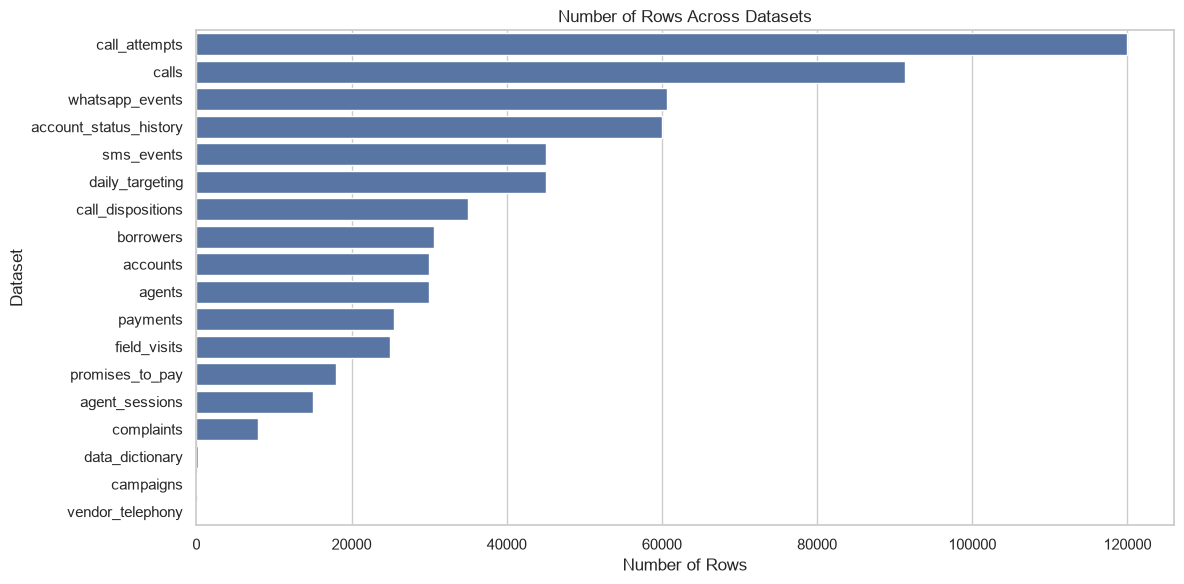

In [103]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=dataset_size_df,
    x="rows",
    y="dataset"
)

plt.title("Number of Rows Across Datasets")
plt.xlabel("Number of Rows")
plt.ylabel("Dataset")

plt.tight_layout()
plt.show()

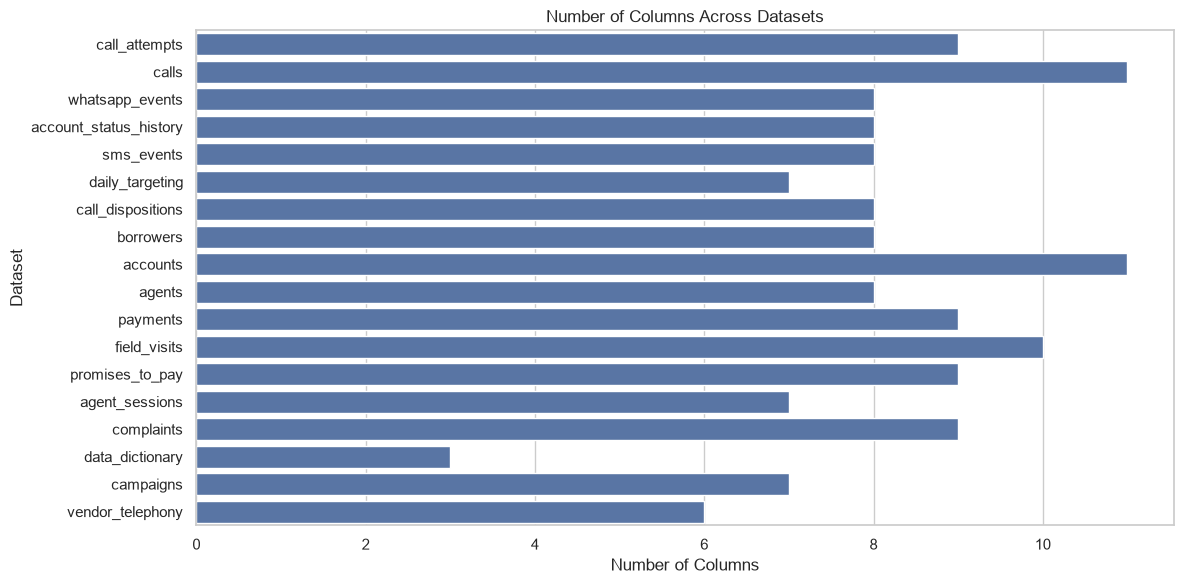

In [104]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=dataset_size_df,
    x="columns",
    y="dataset"
)

plt.title("Number of Columns Across Datasets")
plt.xlabel("Number of Columns")
plt.ylabel("Dataset")

plt.tight_layout()
plt.show()

In [105]:
missing_values_visual = []

for dataset_name, dataframe in datasets.items():
    
    missing_count = dataframe.isnull().sum().sum()
    
    missing_values_visual.append(
        {
            "dataset": dataset_name,
            "missing_values": missing_count
        }
    )

missing_values_visual_df = pd.DataFrame(
    missing_values_visual
).sort_values(
    by="missing_values",
    ascending=False
).reset_index(drop=True)

missing_values_visual_df

,dataset,missing_values
0,call_attempts,2400
1,calls,1827
2,borrowers,1509
3,accounts,455
4,payments,382
5,field_visits,250
6,account_status_history,0
7,call_dispositions,0
8,agents,0
9,agent_sessions,0


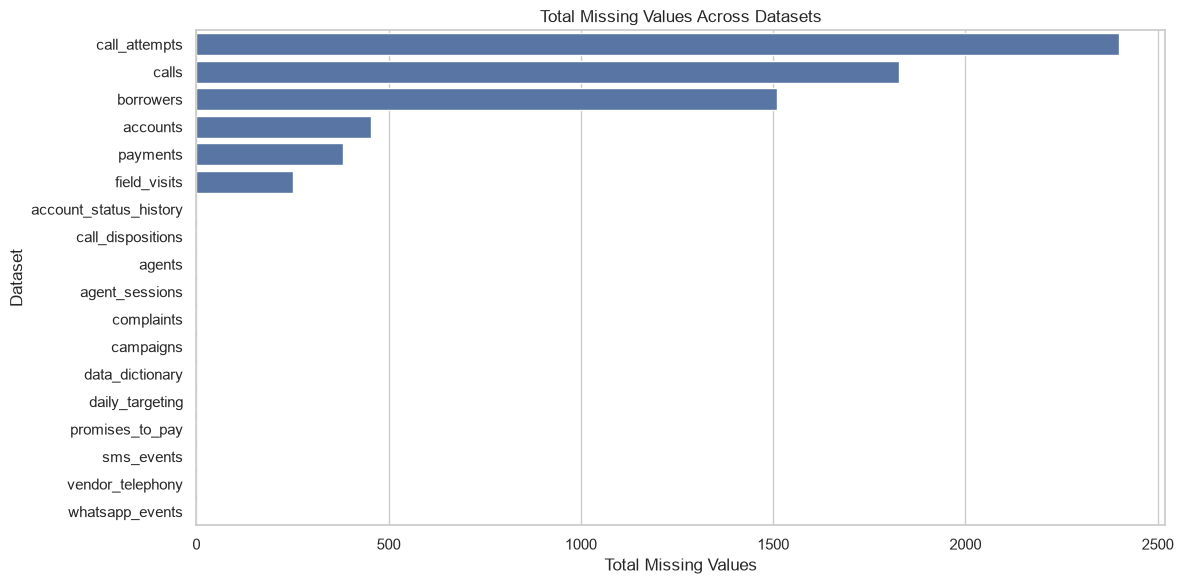

In [106]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=missing_values_visual_df,
    x="missing_values",
    y="dataset"
)

plt.title("Total Missing Values Across Datasets")
plt.xlabel("Total Missing Values")
plt.ylabel("Dataset")

plt.tight_layout()
plt.show()

In [107]:
numerical_columns_summary = []

for dataset_name, dataframe in datasets.items():
    
    numerical_columns = dataframe.select_dtypes(
        include=["int64", "float64", "int32", "float32"]
    ).columns.tolist()
    
    numerical_columns_summary.append(
        {
            "dataset": dataset_name,
            "numerical_columns": len(numerical_columns)
        }
    )

numerical_columns_df = pd.DataFrame(
    numerical_columns_summary
)

numerical_columns_df

,dataset,numerical_columns
0,accounts,3
1,account_status_history,0
2,agents,0
3,agent_sessions,0
4,borrowers,1
5,calls,1
6,call_attempts,1
7,call_dispositions,0
8,campaigns,0
9,complaints,0


In [108]:
selected_dataset_name = None

for dataset_name, dataframe in datasets.items():
    
    numerical_columns = dataframe.select_dtypes(
        include=["number"]
    ).columns.tolist()
    
    if len(numerical_columns) > 0:
        selected_dataset_name = dataset_name
        break

print("Selected dataset:", selected_dataset_name)

Selected dataset: accounts


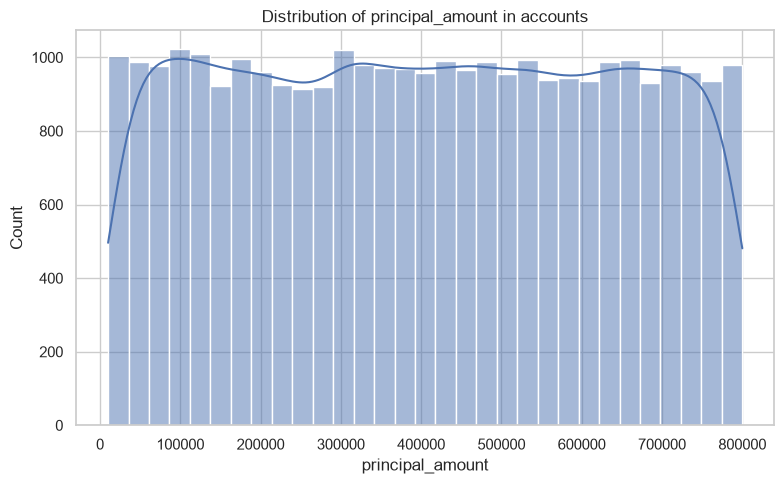

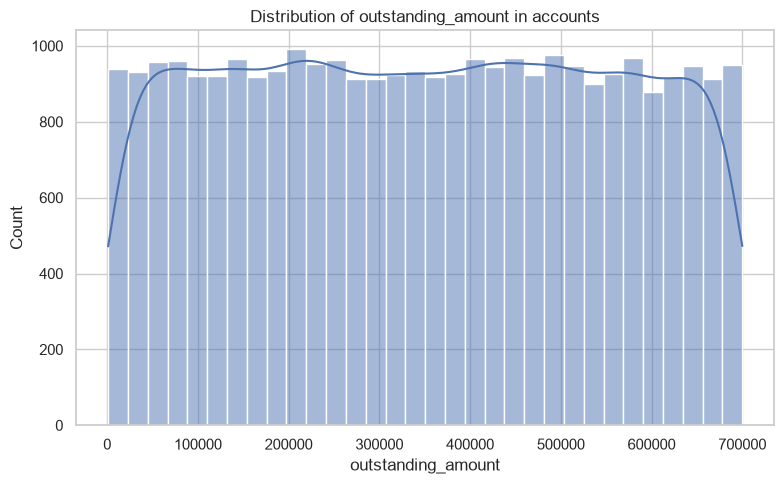

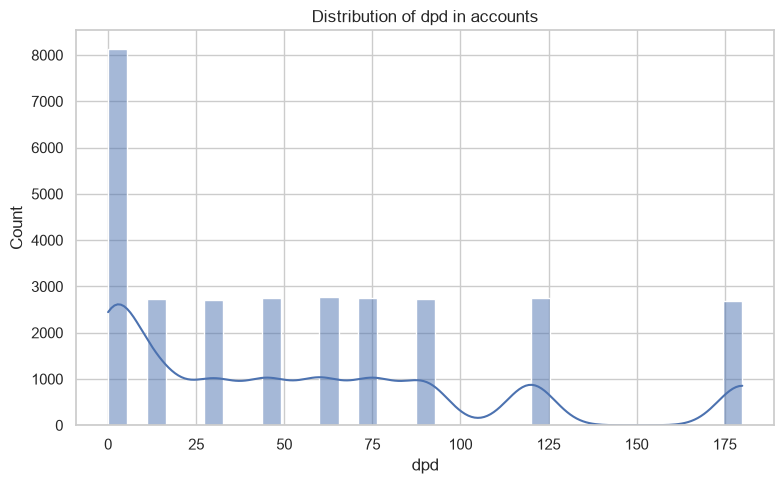

In [109]:
if selected_dataset_name is not None:
    
    selected_dataframe = datasets[selected_dataset_name]
    
    numerical_columns = selected_dataframe.select_dtypes(
        include=["number"]
    ).columns.tolist()
    
    selected_numerical_columns = numerical_columns[:6]
    
    for column in selected_numerical_columns:
        
        plt.figure(figsize=(8, 5))
        
        sns.histplot(
            data=selected_dataframe,
            x=column,
            kde=True
        )
        
        plt.title(
            f"Distribution of {column} in {selected_dataset_name}"
        )
        
        plt.tight_layout()
        plt.show()

else:
    print("No numerical columns found.")

In [110]:
if selected_dataset_name is not None:
    
    selected_dataframe = datasets[selected_dataset_name]
    
    numerical_data = selected_dataframe.select_dtypes(
        include=["number"]
    )
    
    if numerical_data.shape[1] >= 2:
        
        correlation_matrix = numerical_data.corr()
        
        correlation_matrix
    
    else:
        print("Not enough numerical columns for correlation analysis.")

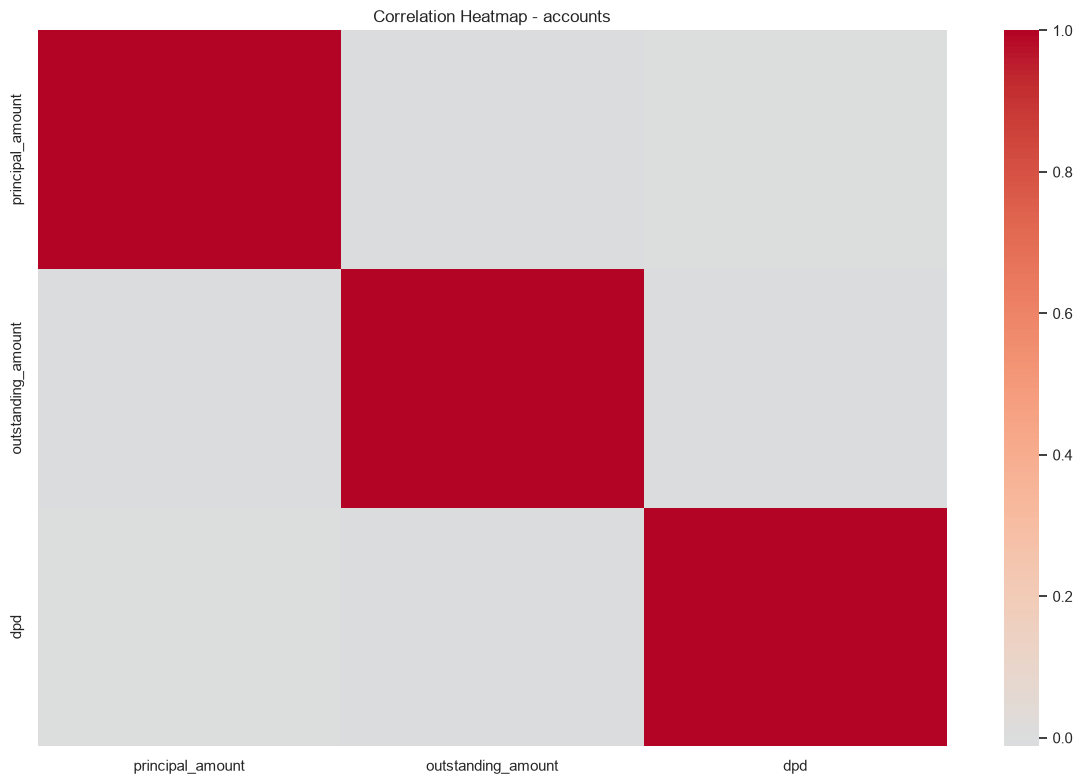

In [111]:
if selected_dataset_name is not None:
    
    selected_dataframe = datasets[selected_dataset_name]
    
    numerical_data = selected_dataframe.select_dtypes(
        include=["number"]
    )
    
    if numerical_data.shape[1] >= 2:
        
        correlation_matrix = numerical_data.corr()
        
        plt.figure(figsize=(12, 8))
        
        sns.heatmap(
            correlation_matrix,
            cmap="coolwarm",
            center=0
        )
        
        plt.title(
            f"Correlation Heatmap - {selected_dataset_name}"
        )
        
        plt.tight_layout()
        plt.show()
        
    else:
        print("Not enough numerical columns for heatmap.")

In [112]:
categorical_columns_summary = []

for dataset_name, dataframe in datasets.items():
    
    categorical_columns = dataframe.select_dtypes(
        include=["object", "category"]
    ).columns.tolist()
    
    categorical_columns_summary.append(
        {
            "dataset": dataset_name,
            "categorical_columns": len(categorical_columns)
        }
    )

categorical_columns_df = pd.DataFrame(
    categorical_columns_summary
)

categorical_columns_df

C:\Users\lenovo\AppData\Local\Temp\ipykernel_5304\2343087632.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = dataframe.select_dtypes(
C:\Users\lenovo\AppData\Local\Temp\ipykernel_5304\2343087632.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migratio

,dataset,categorical_columns
0,accounts,8
1,account_status_history,8
2,agents,8
3,agent_sessions,7
4,borrowers,7
5,calls,10
6,call_attempts,8
7,call_dispositions,8
8,campaigns,7
9,complaints,9


C:\Users\lenovo\AppData\Local\Temp\ipykernel_5304\1374290301.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = dataframe.select_dtypes(


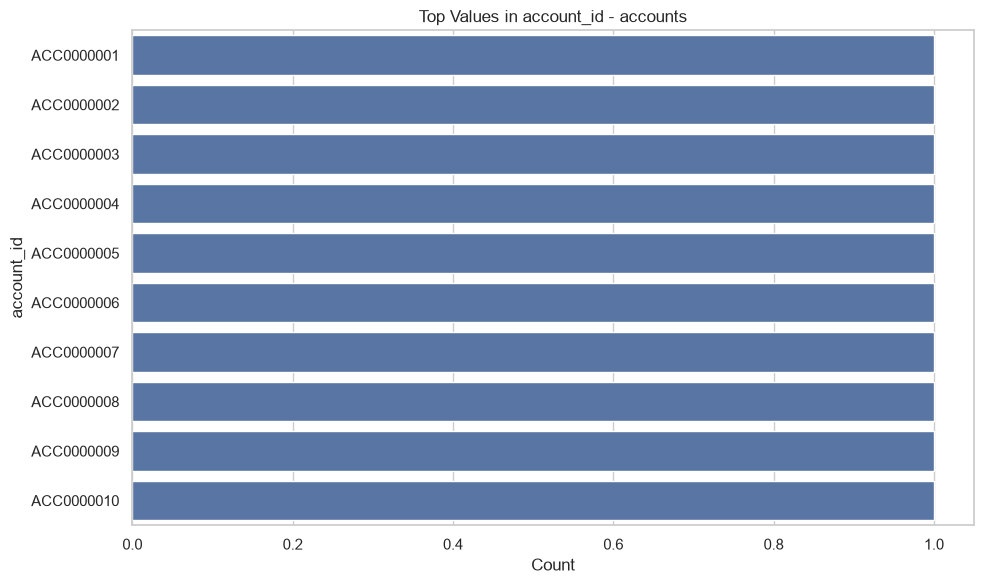

C:\Users\lenovo\AppData\Local\Temp\ipykernel_5304\1374290301.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = dataframe.select_dtypes(


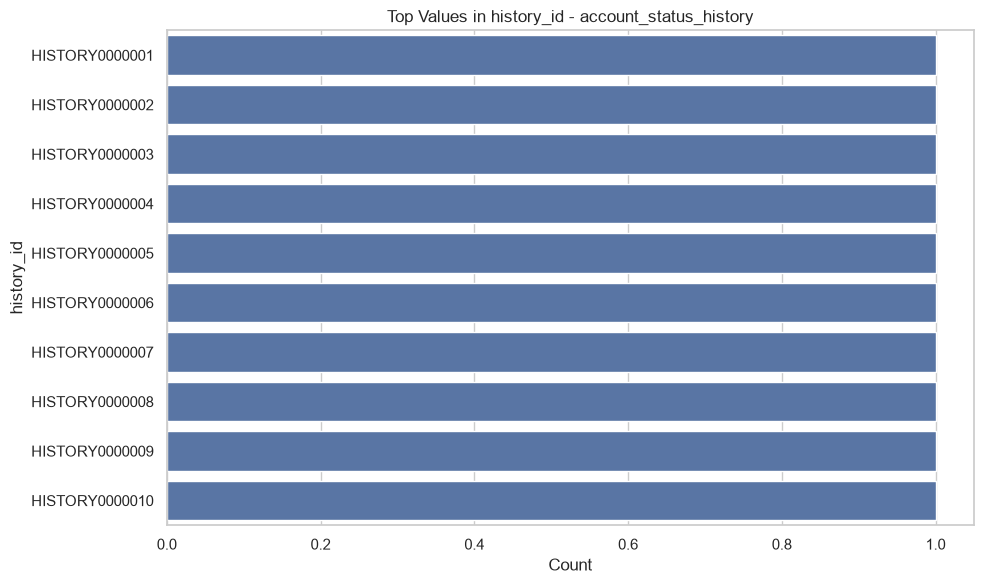

C:\Users\lenovo\AppData\Local\Temp\ipykernel_5304\1374290301.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = dataframe.select_dtypes(


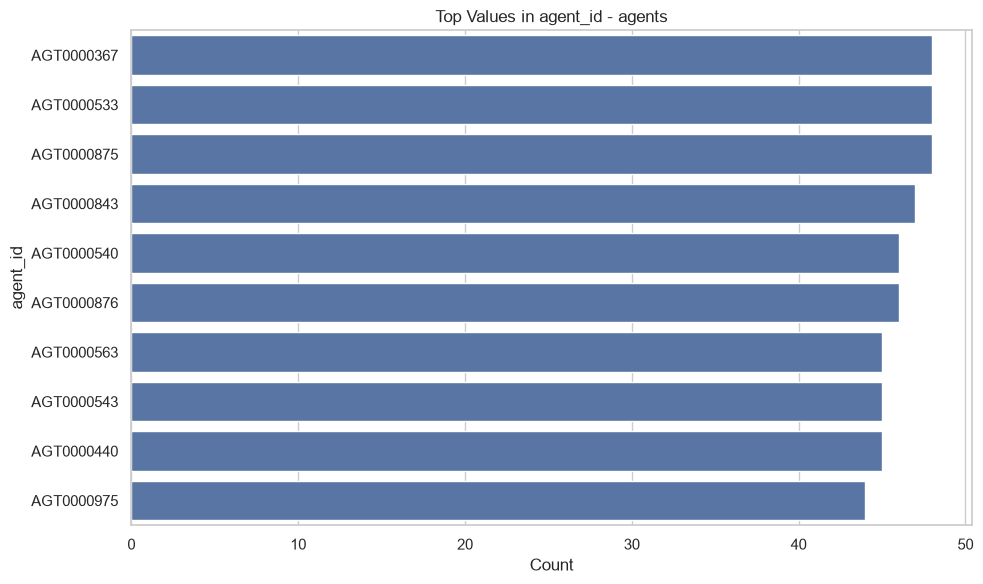

C:\Users\lenovo\AppData\Local\Temp\ipykernel_5304\1374290301.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = dataframe.select_dtypes(


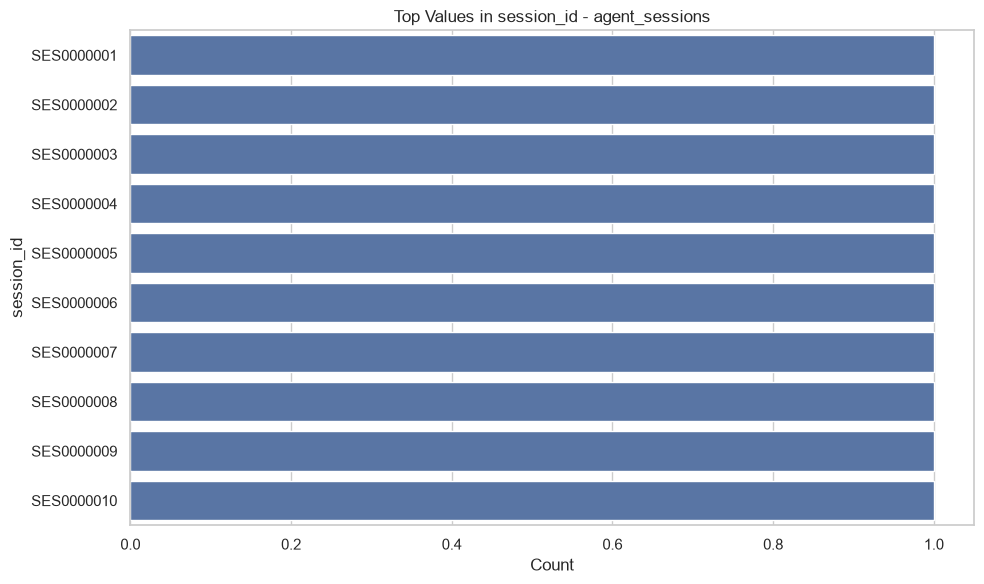

C:\Users\lenovo\AppData\Local\Temp\ipykernel_5304\1374290301.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = dataframe.select_dtypes(


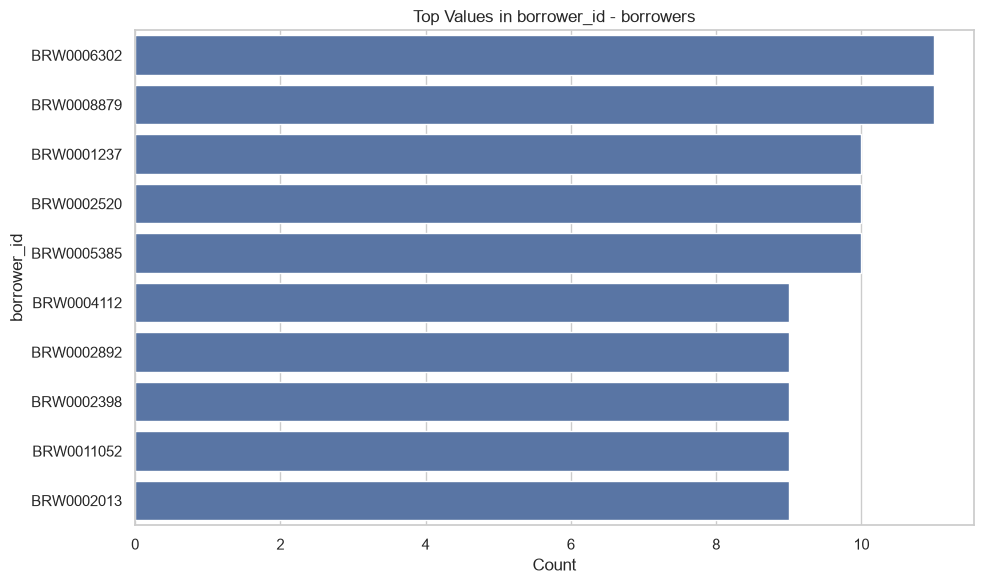

C:\Users\lenovo\AppData\Local\Temp\ipykernel_5304\1374290301.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = dataframe.select_dtypes(


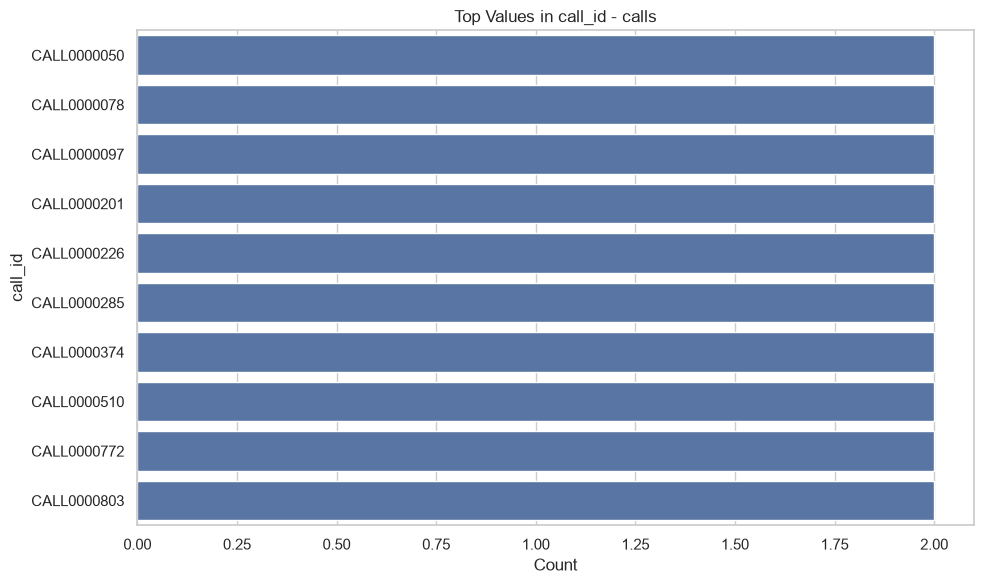

C:\Users\lenovo\AppData\Local\Temp\ipykernel_5304\1374290301.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = dataframe.select_dtypes(


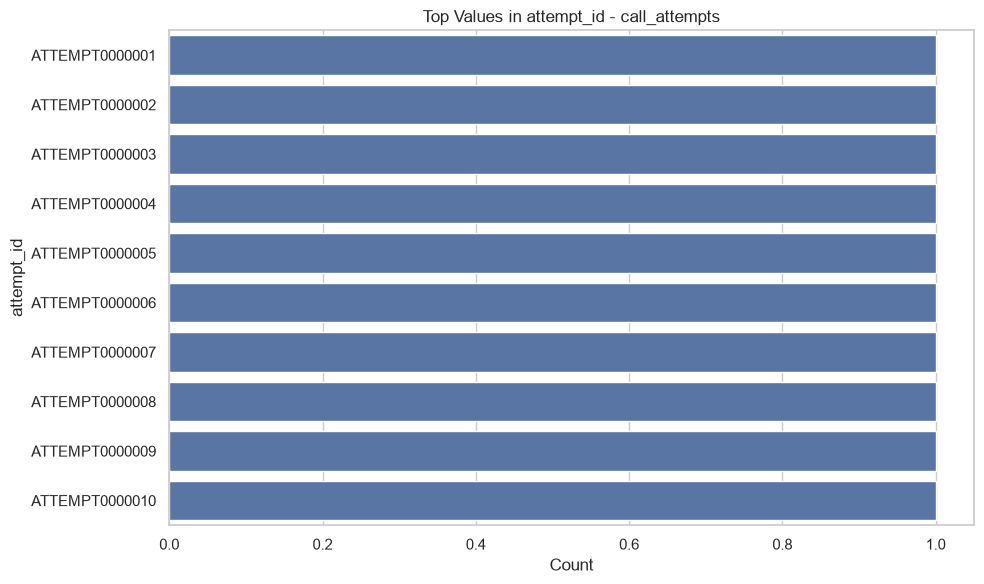

C:\Users\lenovo\AppData\Local\Temp\ipykernel_5304\1374290301.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = dataframe.select_dtypes(


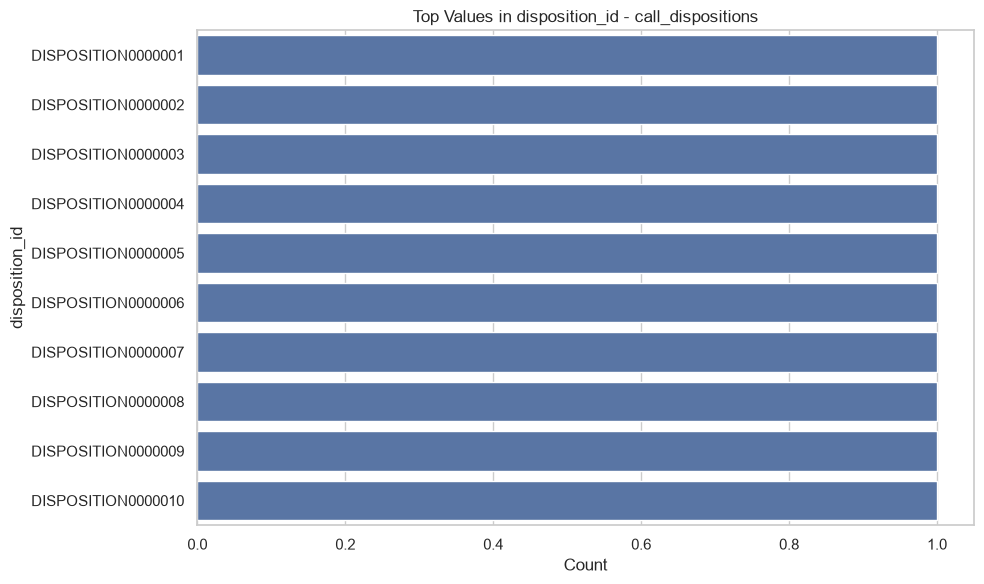

C:\Users\lenovo\AppData\Local\Temp\ipykernel_5304\1374290301.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = dataframe.select_dtypes(


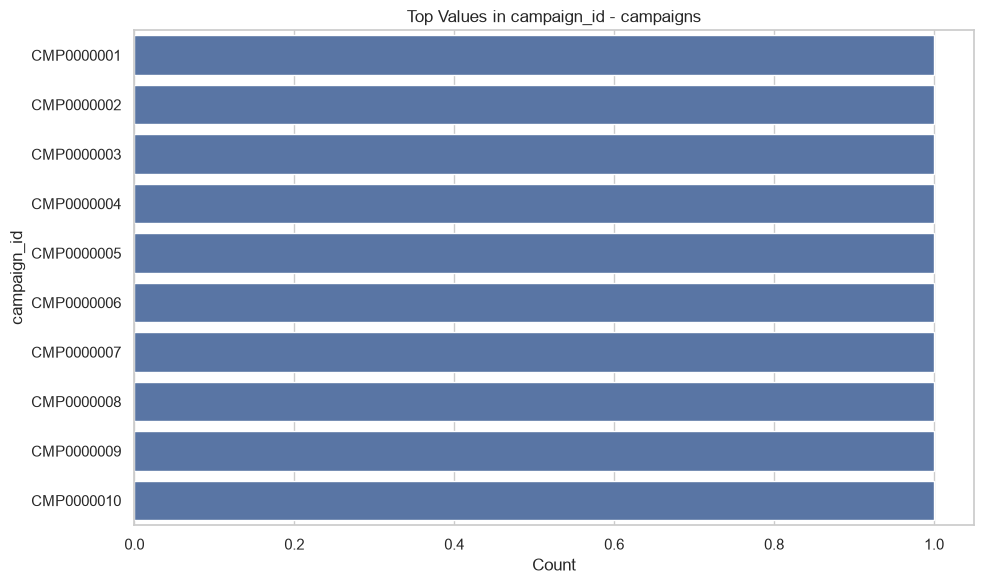

C:\Users\lenovo\AppData\Local\Temp\ipykernel_5304\1374290301.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = dataframe.select_dtypes(


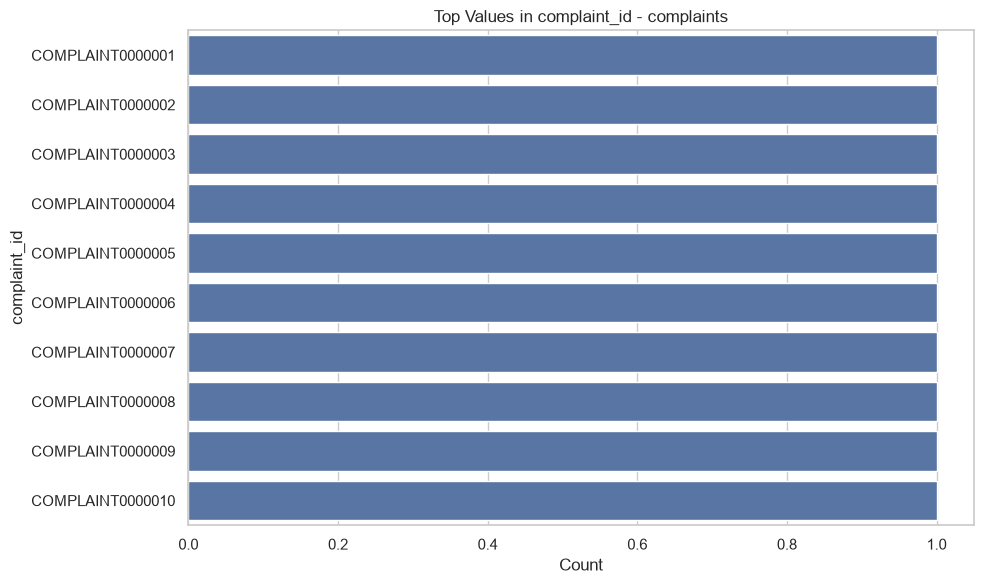

C:\Users\lenovo\AppData\Local\Temp\ipykernel_5304\1374290301.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = dataframe.select_dtypes(


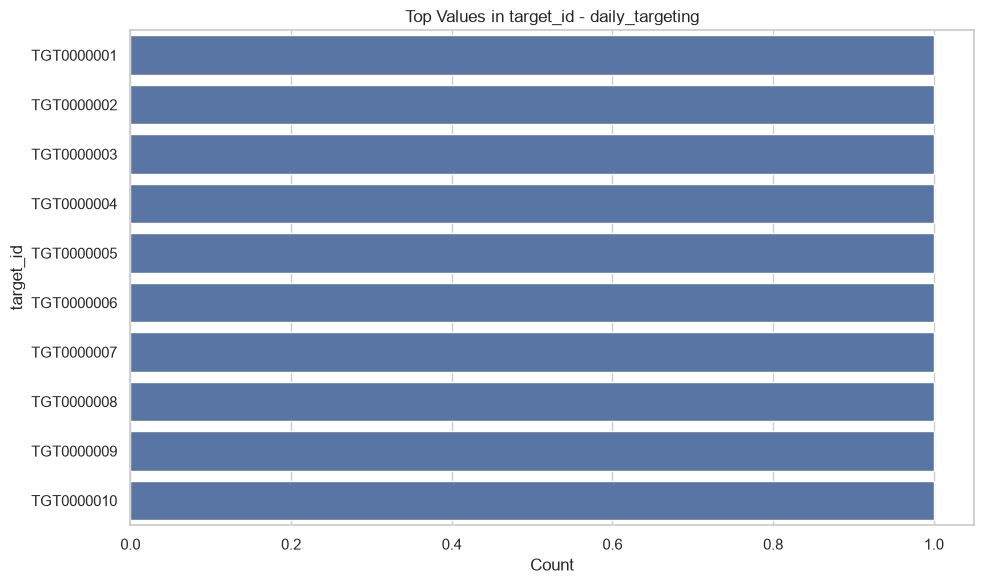

C:\Users\lenovo\AppData\Local\Temp\ipykernel_5304\1374290301.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = dataframe.select_dtypes(


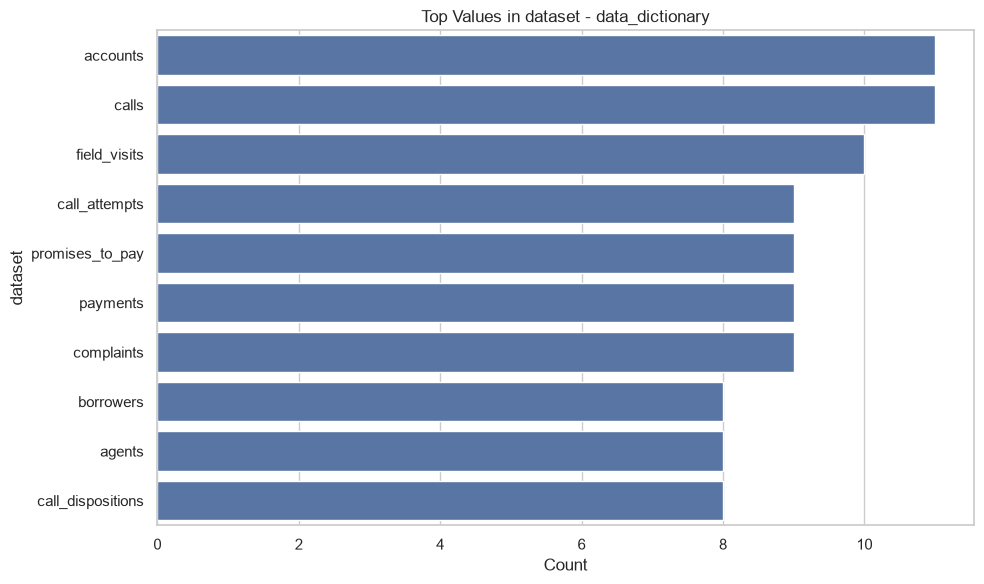

C:\Users\lenovo\AppData\Local\Temp\ipykernel_5304\1374290301.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = dataframe.select_dtypes(


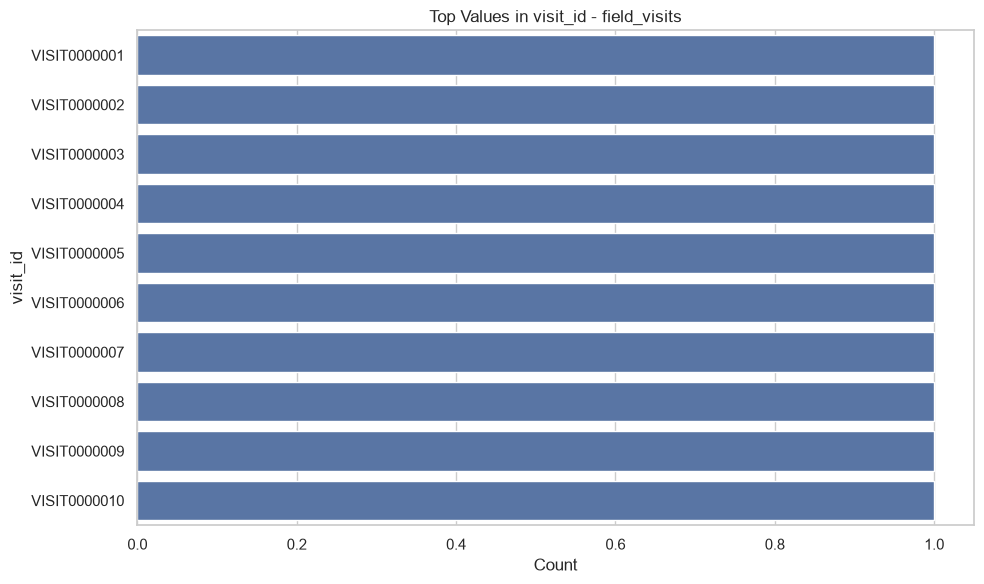

C:\Users\lenovo\AppData\Local\Temp\ipykernel_5304\1374290301.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = dataframe.select_dtypes(


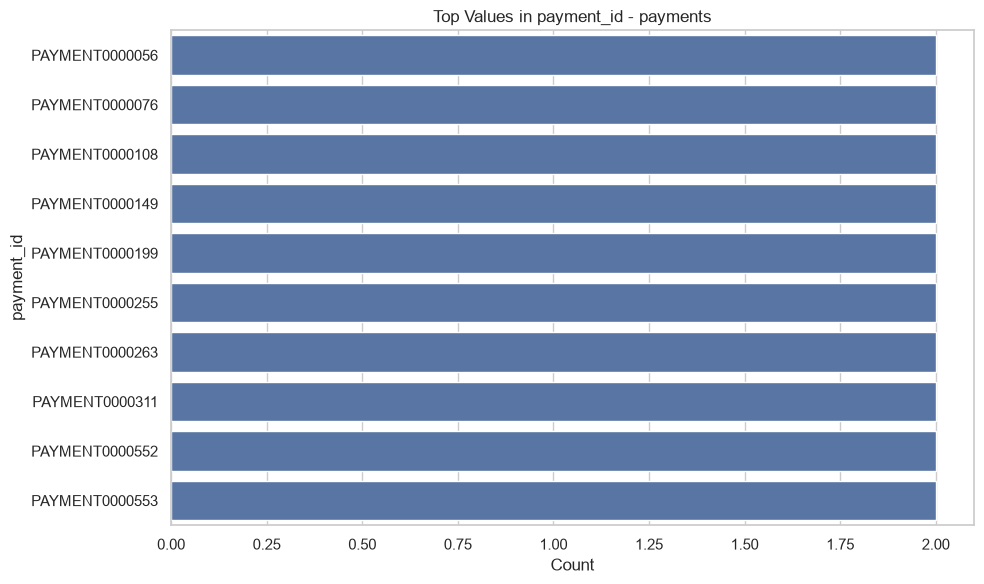

C:\Users\lenovo\AppData\Local\Temp\ipykernel_5304\1374290301.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = dataframe.select_dtypes(


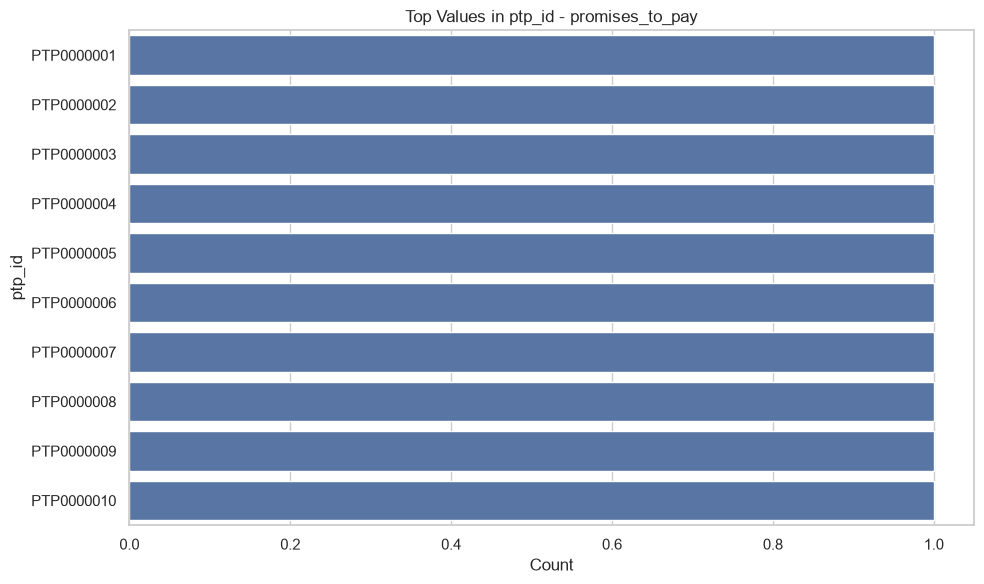

C:\Users\lenovo\AppData\Local\Temp\ipykernel_5304\1374290301.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = dataframe.select_dtypes(


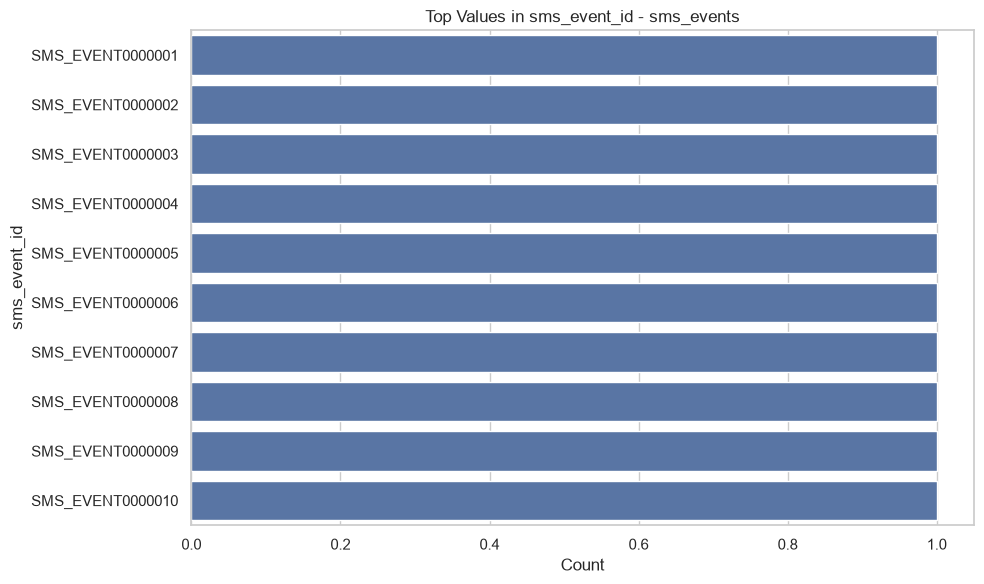

C:\Users\lenovo\AppData\Local\Temp\ipykernel_5304\1374290301.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = dataframe.select_dtypes(


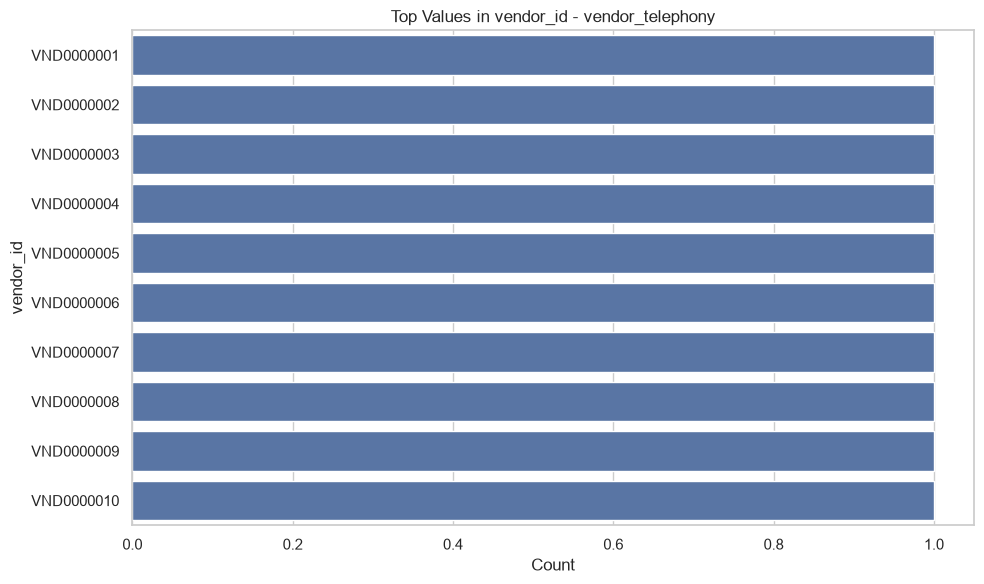

C:\Users\lenovo\AppData\Local\Temp\ipykernel_5304\1374290301.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = dataframe.select_dtypes(


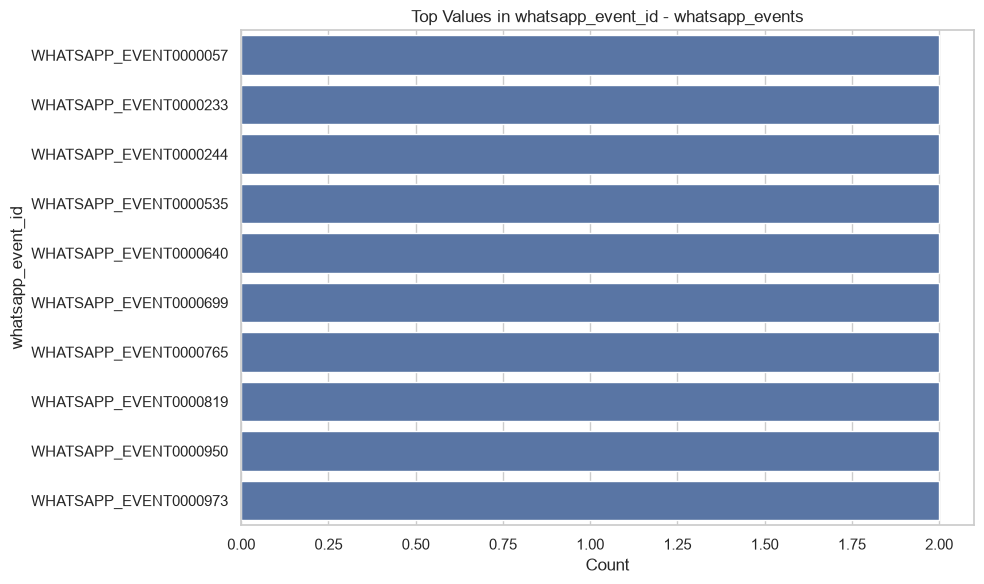

In [113]:
for dataset_name, dataframe in datasets.items():
    
    categorical_columns = dataframe.select_dtypes(
        include=["object", "category"]
    ).columns.tolist()
    
    if len(categorical_columns) > 0:
        
        column = categorical_columns[0]
        
        top_categories = dataframe[column].value_counts().head(10)
        
        if len(top_categories) > 0:
            
            plt.figure(figsize=(10, 6))
            
            sns.barplot(
                x=top_categories.values,
                y=top_categories.index
            )
            
            plt.title(
                f"Top Values in {column} - {dataset_name}"
            )
            
            plt.xlabel("Count")
            plt.ylabel(column)
            
            plt.tight_layout()
            plt.show()

In [114]:
os.makedirs(
    "output/visualizations",
    exist_ok=True
)

dataset_size_df.to_csv(
    "output/visualizations/dataset_size_summary.csv",
    index=False
)

missing_values_visual_df.to_csv(
    "output/visualizations/missing_values_visual_summary.csv",
    index=False
)

numerical_columns_df.to_csv(
    "output/visualizations/numerical_columns_summary.csv",
    index=False
)

categorical_columns_df.to_csv(
    "output/visualizations/categorical_columns_summary.csv",
    index=False
)

print("Step 14 visualization summaries saved successfully!")

Step 14 visualization summaries saved successfully!
